Plot LH & SH

In [1]:
cd ~/Pythons

/home/users/guicha/Pythons


In [2]:
import sys
import os
import numpy as np
import numpy.ma as ma
import xarray as xr
import matplotlib.pyplot as plt
import itertools
import seaborn as sb

from matplotlib.colors import BoundaryNorm
from scipy.stats import pearsonr
from global_land_mask import is_land

from KSCALE.read_data.read_data_catalog import load_data_global, load_data_regional
from KSCALE.p_config import regions, proj

/home/users/guicha/.conda/envs/hk25/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
region='Africa'
zoom = 7
years = np.arange(2020, 2021+1)

ts = '1D'  # resampling timescale
rwindow = 10

lat_range = regions[region][0]
lon_range = regions[region][1]
lat_min = lat_range[0]
lat_max = lat_range[1]
lon_min = lon_range[0]
lon_max = lon_range[1]

In [4]:
#~ Get data

data_gal_lh = []
data_gal_sh = []
data_com_lh = []
data_com_sh = []
data_ral_lh = []
data_ral_sh = []
data_ctc_lh = []
data_ctc_sh = []
data_lam_lh = []
data_lam_sh = []

for year in years:
    print(year)
    data_gal_lh_ = load_data_global(resolution='n1280', driving='GAL9', zoom=zoom, variable='hflsd',
                                 lat_range=lat_range, lon_range=lon_range, year=year, timescale=ts)
    data_gal_sh_ = load_data_global(resolution='n1280', driving='GAL9', zoom=zoom, variable='hfssd',
                                 lat_range=lat_range, lon_range=lon_range, year=year, timescale=ts)
    data_com_lh_ = load_data_global(resolution='n1280', driving='CoMA9_TBv1p2', zoom=zoom, variable='hflsd',
                                 lat_range=lat_range, lon_range=lon_range, year=year, timescale=ts)
    data_com_sh_ = load_data_global(resolution='n1280', driving='CoMA9_TBv1p2', zoom=zoom, variable='hfssd',
                                 lat_range=lat_range, lon_range=lon_range, year=year, timescale=ts)
    data_ral_lh_ = load_data_global(resolution='n2560', driving='RAL3p3', zoom=zoom, variable='hflsd',
                                 lat_range=lat_range, lon_range=lon_range, year=year, timescale=ts)
    data_ral_sh_ = load_data_global(resolution='n2560', driving='RAL3p3', zoom=zoom, variable='hfssd',
                                 lat_range=lat_range, lon_range=lon_range, year=year, timescale=ts)
    data_ctc_lh_ = load_data_regional(region='CTC', resolution='km4p4', physics='RAL3P3', driving='GAL9', reso_nest='n1280', zoom=zoom, variable='hflsd',
                                 lat_range=lat_range, lon_range=lon_range, year=year, timescale=ts)
    data_ctc_sh_ = load_data_regional(region='CTC', resolution='km4p4', physics='RAL3P3', driving='GAL9', reso_nest='n1280', zoom=zoom, variable='hfssd',
                                 lat_range=lat_range, lon_range=lon_range, year=year, timescale=ts)
    if region == 'Africa':
        data_lam_lh_ = load_data_regional(region=region, resolution='km4p4', physics='RAL3P3', driving='GAL9', reso_nest='n1280', zoom=zoom, variable='hflsd',
                                 lat_range=lat_range, lon_range=lon_range, year=year, timescale=ts)
        data_lam_sh_ = load_data_regional(region=region, resolution='km4p4', physics='RAL3P3', driving='GAL9', reso_nest='n1280', zoom=zoom, variable='hfssd',
                                 lat_range=lat_range, lon_range=lon_range, year=year, timescale=ts)
        data_lam_lh.append(data_lam_lh_)
        data_lam_sh.append(data_lam_sh_)

    data_gal_lh.append(data_gal_lh_)
    data_gal_sh.append(data_gal_sh_)
    data_com_lh.append(data_com_lh_)
    data_com_sh.append(data_com_sh_)
    data_ral_lh.append(data_ral_lh_)
    data_ral_sh.append(data_ral_sh_)
    data_ctc_lh.append(data_ctc_lh_)
    data_ctc_sh.append(data_ctc_sh_)

data_gal_lh = xr.concat(data_gal_lh, dim='time').dropna(dim='time')
data_gal_sh = xr.concat(data_gal_sh, dim='time').dropna(dim='time')rad
data_com_lh = xr.concat(data_com_lh, dim='time').dropna(dim='time')
data_com_sh = xr.concat(data_com_sh, dim='time').dropna(dim='time')
data_ral_lh = xr.concat(data_ral_lh, dim='time').dropna(dim='time')
data_ral_sh = xr.concat(data_ral_sh, dim='time').dropna(dim='time')
data_ctc_lh = xr.concat(data_ctc_lh, dim='time').dropna(dim='time')
data_ctc_sh = xr.concat(data_ctc_sh, dim='time').dropna(dim='time')

if region == 'Africa':
    data_lam_lh = xr.concat(data_lam_lh, dim='time').dropna(dim='time')
    data_lam_sh = xr.concat(data_lam_sh, dim='time').dropna(dim='time')
    data_lam_lh_rm = data_lam_lh.rolling(time=rwindow, center=True).mean()
    data_lam_sh_rm = data_lam_sh.rolling(time=rwindow, center=True).mean()
    data_lam_lh_ano = data_lam_lh - data_lam_lh_rm
    data_lam_sh_ano = data_lam_sh - data_lam_sh_rm
    data_lam_lh_ano = data_lam_lh_ano.isel(time=slice(0+int(rwindow/2), len(data_lam_lh_ano.time)-int(rwindow/2)+1))
    data_lam_sh_ano = data_lam_sh_ano.isel(time=slice(0+int(rwindow/2), len(data_lam_sh_ano.time)-int(rwindow/2)+1))

data_gal_lh = data_gal_lh.isel(time=slice(0, len(data_gal_lh.time)-1))
data_gal_sh = data_gal_sh.isel(time=slice(0, len(data_gal_sh.time)-1))
data_com_lh = data_com_lh.isel(time=slice(0, len(data_com_lh.time)-1))
data_com_sh = data_com_sh.isel(time=slice(0, len(data_com_sh.time)-1))
data_ral_lh = data_ral_lh.isel(time=slice(0, len(data_ral_lh.time)-1))
data_ral_sh = data_ral_sh.isel(time=slice(0, len(data_ral_sh.time)-1))
data_ctc_lh = data_ctc_lh.isel(time=slice(0, len(data_ctc_lh.time)-1))
data_ctc_sh = data_ctc_sh.isel(time=slice(0, len(data_ctc_sh.time)-1))

2020
2021


In [5]:
dx = abs(abs(data_gal_lh.lon.values[1]) - abs(data_gal_lh.lon.values[0])) * 100
dy = abs(abs(data_gal_lh.lat.values[1]) - abs(data_gal_lh.lat.values[0])) * 100
(dx, dy)

(np.float64(33.488372093023244), np.float64(33.519553072625996))

In [6]:
#~ Extract high-frequency (day-to-day) variability

data_gal_lh_rm = data_gal_lh.rolling(time=rwindow, center=True).mean()
data_gal_sh_rm = data_gal_sh.rolling(time=rwindow, center=True).mean()
data_com_lh_rm = data_com_lh.rolling(time=rwindow, center=True).mean()
data_com_sh_rm = data_com_sh.rolling(time=rwindow, center=True).mean()
data_ral_lh_rm = data_ral_lh.rolling(time=rwindow, center=True).mean()
data_ral_sh_rm = data_ral_sh.rolling(time=rwindow, center=True).mean()
data_ctc_lh_rm = data_ctc_lh.rolling(time=rwindow, center=True).mean()
data_ctc_sh_rm = data_ctc_sh.rolling(time=rwindow, center=True).mean()

data_gal_lh_ano = data_gal_lh - data_gal_lh_rm
data_gal_sh_ano = data_gal_sh - data_gal_sh_rm
data_com_lh_ano = data_com_lh - data_com_lh_rm
data_com_sh_ano = data_com_sh - data_com_sh_rm
data_ral_lh_ano = data_ral_lh - data_ral_lh_rm
data_ral_sh_ano = data_ral_sh - data_ral_sh_rm
data_ctc_lh_ano = data_ctc_lh - data_ctc_lh_rm
data_ctc_sh_ano = data_ctc_sh - data_ctc_sh_rm

data_gal_lh_ano = data_gal_lh_ano.isel(time=slice(0+int(rwindow/2), len(data_gal_lh_ano.time)-int(rwindow/2)+1))
data_gal_sh_ano = data_gal_sh_ano.isel(time=slice(0+int(rwindow/2), len(data_gal_sh_ano.time)-int(rwindow/2)+1))
data_com_lh_ano = data_com_lh_ano.isel(time=slice(0+int(rwindow/2), len(data_gal_lh_ano.time)-int(rwindow/2)+1))
data_com_sh_ano = data_com_sh_ano.isel(time=slice(0+int(rwindow/2), len(data_gal_sh_ano.time)-int(rwindow/2)+1))
data_ral_lh_ano = data_ral_lh_ano.isel(time=slice(0+int(rwindow/2), len(data_ral_lh_ano.time)-int(rwindow/2)+1))
data_ral_sh_ano = data_ral_sh_ano.isel(time=slice(0+int(rwindow/2), len(data_ral_sh_ano.time)-int(rwindow/2)+1))
data_ctc_lh_ano = data_ctc_lh_ano.isel(time=slice(0+int(rwindow/2), len(data_ctc_lh_ano.time)-int(rwindow/2)+1))
data_ctc_sh_ano = data_ctc_sh_ano.isel(time=slice(0+int(rwindow/2), len(data_ctc_sh_ano.time)-int(rwindow/2)+1))

In [7]:
print(data_gal_lh_ano.sel(lat=10, lon=10, method='nearest').std().values,
data_ral_lh_ano.sel(lat=10, lon=10, method='nearest').std().values,
data_ctc_lh_ano.sel(lat=10, lon=10, method='nearest').std().values,
data_lam_lh_ano.sel(lat=10, lon=10, method='nearest').std().values)

print(data_gal_sh_ano.sel(lat=10, lon=10, method='nearest').std().values,
data_ral_sh_ano.sel(lat=10, lon=10, method='nearest').std().values,
data_ctc_sh_ano.sel(lat=10, lon=10, method='nearest').std().values,
data_lam_sh_ano.sel(lat=10, lon=10, method='nearest').std().values)

11.28217 10.035578 12.568121 10.938385
6.590226 5.6406193 8.313755 9.194995


In [8]:
#~ Get point value

lat_pt = 0
lon_pt = -50

data_gal_lh_pt = data_gal_lh.sel(lat=lat_pt, lon=lon_pt, method='nearest')
data_gal_sh_pt = data_gal_sh.sel(lat=lat_pt, lon=lon_pt, method='nearest')
data_com_lh_pt = data_com_lh.sel(lat=lat_pt, lon=lon_pt, method='nearest')
data_com_sh_pt = data_com_sh.sel(lat=lat_pt, lon=lon_pt, method='nearest')
data_ral_lh_pt = data_ral_lh.sel(lat=lat_pt, lon=lon_pt, method='nearest')
data_ral_sh_pt = data_ral_sh.sel(lat=lat_pt, lon=lon_pt, method='nearest')
data_ctc_lh_pt = data_ctc_lh.sel(lat=lat_pt, lon=lon_pt, method='nearest')
data_ctc_sh_pt = data_ctc_sh.sel(lat=lat_pt, lon=lon_pt, method='nearest')
if region == 'Africa':
    data_lam_lh_pt = data_lam_lh.sel(lat=lat_pt, lon=lon_pt, method='nearest')
    data_lam_sh_pt = data_lam_sh.sel(lat=lat_pt, lon=lon_pt, method='nearest')

data_gal_lh_pt_rm = data_gal_lh_rm.sel(lat=lat_pt, lon=lon_pt, method='nearest')  #data_gal_lh_pt - data_gal_lh_pt_rm
data_gal_sh_pt_rm = data_gal_sh_rm.sel(lat=lat_pt, lon=lon_pt, method='nearest')  # data_gal_sh_pt - data_gal_sh_pt_rm

data_gal_lh_pt_ano = data_gal_lh_ano.sel(lat=lat_pt, lon=lon_pt, method='nearest')  #data_gal_lh_pt - data_gal_lh_pt_rm
data_gal_sh_pt_ano = data_gal_sh_ano.sel(lat=lat_pt, lon=lon_pt, method='nearest')  # data_gal_sh_pt - data_gal_sh_pt_rm
data_com_lh_pt_ano = data_com_lh_ano.sel(lat=lat_pt, lon=lon_pt, method='nearest')  #data_gal_lh_pt - data_gal_lh_pt_rm
data_com_sh_pt_ano = data_com_sh_ano.sel(lat=lat_pt, lon=lon_pt, method='nearest')  # data_gal_sh_pt - data_gal_sh_pt_rm
data_ral_lh_pt_ano = data_ral_lh_ano.sel(lat=lat_pt, lon=lon_pt, method='nearest')  #data_gal_lh_pt - data_gal_lh_pt_rm
data_ral_sh_pt_ano = data_ral_sh_ano.sel(lat=lat_pt, lon=lon_pt, method='nearest')  # data_gal_sh_pt - data_gal_sh_pt_rm
data_ctc_lh_pt_ano = data_ctc_lh_ano.sel(lat=lat_pt, lon=lon_pt, method='nearest')  #data_gal_lh_pt - data_gal_lh_pt_rm
data_ctc_sh_pt_ano = data_ctc_sh_ano.sel(lat=lat_pt, lon=lon_pt, method='nearest')  # data_gal_sh_pt - data_gal_sh_pt_rm
if region == 'Africa':
    data_lam_lh_pt_ano = data_lam_lh_ano.sel(lat=lat_pt, lon=lon_pt, method='nearest')  #data_gal_lh_pt - data_gal_lh_pt_rm
    data_lam_sh_pt_ano = data_lam_sh_ano.sel(lat=lat_pt, lon=lon_pt, method='nearest')  # data_gal_sh_pt - data_gal_sh_pt_rm

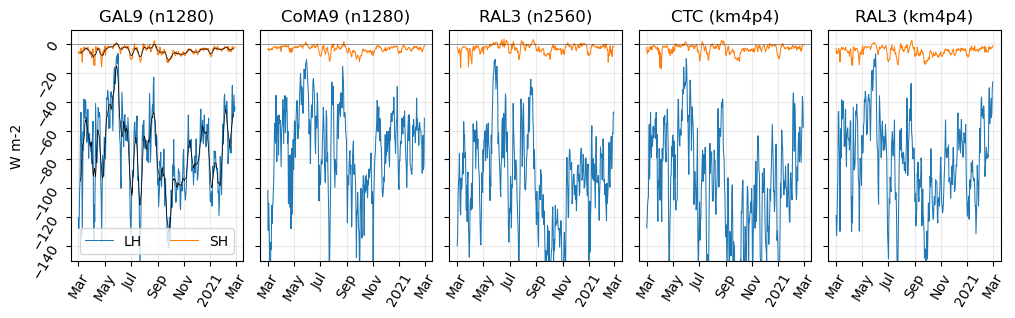

In [9]:
ylims = (-150., 10.)


fig, ax = plt.subplots(ncols=5)

plt.subplots_adjust(wspace=0.1)

data_gal_lh_pt.plot(ax=ax[0], lw=0.75, label='LH')
data_gal_lh_pt_rm.plot(ax=ax[0], lw=0.5, color='k')

data_gal_sh_pt.plot(ax=ax[0], lw=0.75, label='SH')
data_gal_sh_pt_rm.plot(ax=ax[0], lw=0.5, color='k')

data_com_lh_pt.plot(ax=ax[1], lw=0.75)
data_com_sh_pt.plot(ax=ax[1], lw=0.75)
data_ral_lh_pt.plot(ax=ax[2], lw=0.75)
data_ral_sh_pt.plot(ax=ax[2], lw=0.75)
data_ctc_lh_pt.plot(ax=ax[3], lw=0.75)
data_ctc_sh_pt.plot(ax=ax[3], lw=0.75)
if region == 'Africa':
    data_lam_lh_pt.plot(ax=ax[4], lw=0.75)
    data_lam_sh_pt.plot(ax=ax[4], lw=0.75)

ax[0].axhline(0, 0, 1, lw=0.5, color='k', alpha=0.5)
ax[1].axhline(0, 0, 1, lw=0.5, color='k', alpha=0.5)
ax[2].axhline(0, 0, 1, lw=0.5, color='k', alpha=0.5)
ax[3].axhline(0, 0, 1, lw=0.5, color='k', alpha=0.5)

ax[0].grid(True, alpha=0.25)
ax[1].grid(True, alpha=0.25)
ax[2].grid(True, alpha=0.25)
ax[3].grid(True, alpha=0.25)
ax[4].grid(True, alpha=0.25)
ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[2].set_xlabel('')
ax[3].set_xlabel('')
ax[4].set_xlabel('')
ax[0].set_ylim(ylims)
ax[1].set_ylim(ylims)
ax[2].set_ylim(ylims)
ax[3].set_ylim(ylims)
ax[4].set_ylim(ylims)
ax[1].set_yticklabels([])
ax[2].set_yticklabels([])
ax[3].set_yticklabels([])
ax[4].set_yticklabels([])
ax[0].set_ylabel('W m-2')
ax[1].set_ylabel('')
ax[2].set_ylabel('')
ax[3].set_ylabel('')
ax[4].set_ylabel('')
ax[0].set_title('GAL9 (n1280)')
ax[1].set_title('CoMA9 (n1280)')
ax[2].set_title('RAL3 (n2560)')
ax[3].set_title('CTC (km4p4)')
ax[4].set_title('RAL3 (km4p4)')

ax[0].tick_params(rotation=60)
ax[1].tick_params(rotation=60)
ax[2].tick_params(rotation=60)
ax[3].tick_params(rotation=60)
ax[4].tick_params(rotation=60)

ax[0].legend(loc='lower center', ncol=2)

fig.set_size_inches(12., 3.)

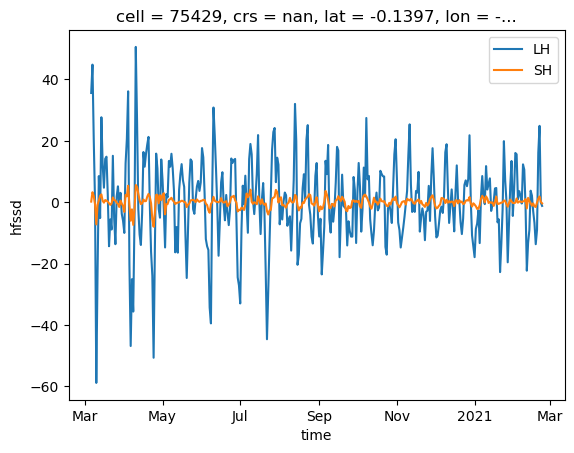

In [10]:
data_gal_lh_pt_ano.plot(label='LH')
data_gal_sh_pt_ano.plot(label='SH')
plt.legend()

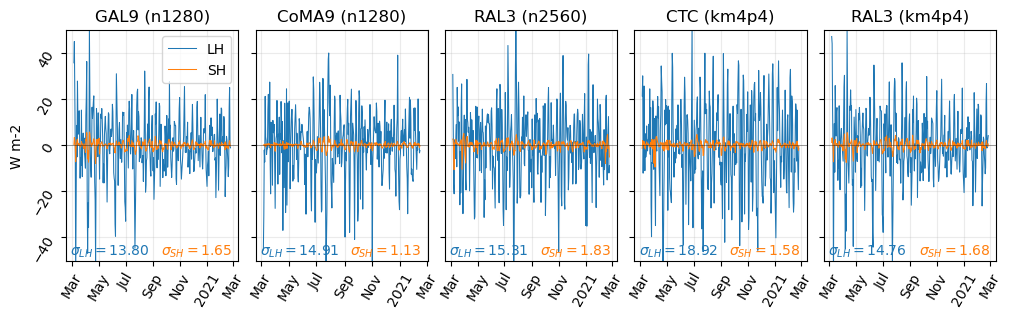

In [11]:
ylims_ano = (-50., 50.)

if region == 'Africa':
    ncols = 5
else:
    ncols = 4

fig, ax = plt.subplots(ncols=ncols)

plt.subplots_adjust(wspace=0.1)

p_lh = data_gal_lh_pt_ano.plot(ax=ax[0], lw=0.75, label='LH')
p_sh = data_gal_sh_pt_ano.plot(ax=ax[0], lw=0.75, label='SH')
data_com_lh_pt_ano.plot(ax=ax[1], lw=0.75, label='LH')
data_com_sh_pt_ano.plot(ax=ax[1], lw=0.75, label='SH')
data_ral_lh_pt_ano.plot(ax=ax[2], lw=0.75, label='LH')
data_ral_sh_pt_ano.plot(ax=ax[2], lw=0.75, label='SH')
data_ctc_lh_pt_ano.plot(ax=ax[3], lw=0.75, label='LH')
data_ctc_sh_pt_ano.plot(ax=ax[3], lw=0.75, label='SH')


col_lh = p_lh[0].get_color()
col_sh = p_sh[0].get_color()

ax[0].text(0.025, 0.025, '$\\sigma_{LH}=%.2f$'%data_gal_lh_pt_ano.std(), color=col_lh, transform=ax[0].transAxes)
ax[0].text(0.55, 0.025, '$\\sigma_{SH}=%.2f$'%data_gal_sh_pt_ano.std(), color=col_sh, transform=ax[0].transAxes)
ax[1].text(0.025, 0.025, '$\\sigma_{LH}=%.2f$'%data_com_lh_pt_ano.std(), color=col_lh, transform=ax[1].transAxes)
ax[1].text(0.55, 0.025, '$\\sigma_{SH}=%.2f$'%data_com_sh_pt_ano.std(), color=col_sh, transform=ax[1].transAxes)
ax[2].text(0.025, 0.025, '$\\sigma_{LH}=%.2f$'%data_ral_lh_pt_ano.std(), color=col_lh, transform=ax[2].transAxes)
ax[2].text(0.55, 0.025, '$\\sigma_{SH}=%.2f$'%data_ral_sh_pt_ano.std(), color=col_sh, transform=ax[2].transAxes)
ax[3].text(0.025, 0.025, '$\\sigma_{LH}=%.2f$'%data_ctc_lh_pt_ano.std(), color=col_lh, transform=ax[3].transAxes)
ax[3].text(0.55, 0.025, '$\\sigma_{SH}=%.2f$'%data_ctc_sh_pt_ano.std(), color=col_sh, transform=ax[3].transAxes)

if region == 'Africa':
    data_lam_lh_pt_ano.plot(ax=ax[4], lw=0.75, label='LH')
    data_lam_sh_pt_ano.plot(ax=ax[4], lw=0.75, label='SH')
    ax[4].text(0.025, 0.025, '$\\sigma_{LH}=%.2f$'%data_lam_lh_pt_ano.std(), color=col_lh, transform=ax[4].transAxes)
    ax[4].text(0.55, 0.025, '$\\sigma_{SH}=%.2f$'%data_lam_sh_pt_ano.std(), color=col_sh, transform=ax[4].transAxes)
    ax[4].axhline(0, 0, 1, lw=0.5, color='k', alpha=0.5)
    ax[4].grid(True, alpha=0.25)
    ax[4].set_xlabel('')
    ax[4].set_ylim(ylims_ano)
    ax[4].set_yticklabels([])
    ax[4].set_ylabel('')
    ax[4].set_title('RAL3 (km4p4)')
    ax[4].tick_params(rotation=60)

ax[0].axhline(0, 0, 1, lw=0.5, color='k', alpha=0.5)
ax[1].axhline(0, 0, 1, lw=0.5, color='k', alpha=0.5)
ax[2].axhline(0, 0, 1, lw=0.5, color='k', alpha=0.5)
ax[3].axhline(0, 0, 1, lw=0.5, color='k', alpha=0.5)

ax[0].legend(loc='upper right', ncol=1)

ax[0].grid(True, alpha=0.25)
ax[1].grid(True, alpha=0.25)
ax[2].grid(True, alpha=0.25)
ax[3].grid(True, alpha=0.25)

ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[2].set_xlabel('')
ax[3].set_xlabel('')
ax[0].set_ylim(ylims_ano)
ax[1].set_ylim(ylims_ano)
ax[2].set_ylim(ylims_ano)
ax[3].set_ylim(ylims_ano)
ax[1].set_yticklabels([])
ax[2].set_yticklabels([])
ax[3].set_yticklabels([])
ax[0].set_ylabel('W m-2')
ax[1].set_ylabel('')
ax[2].set_ylabel('')
ax[3].set_ylabel('')
ax[0].set_title('GAL9 (n1280)')
ax[1].set_title('CoMA9 (n1280)')
ax[2].set_title('RAL3 (n2560)')
ax[3].set_title('CTC (km4p4)')
ax[0].tick_params(rotation=60)
ax[1].tick_params(rotation=60)
ax[2].tick_params(rotation=60)
ax[3].tick_params(rotation=60)

fig.set_size_inches(12., 3.)

In [12]:
imths = data_gal_lh_pt_ano.groupby('time.month').groups
mths = [6, 7, 8]
lmonths = [imths[m] for m in mths]
lmonths = list(itertools.chain(*lmonths))
data_gal_lh_pt_ano_ = data_gal_lh_pt_ano.isel(time=lmonths).dropna(dim='time')
data_gal_sh_pt_ano_ = data_gal_sh_pt_ano.isel(time=lmonths).dropna(dim='time')

pr = pearsonr(data_gal_lh_pt_ano_, data_gal_sh_pt_ano_)
rho = pr[0]
pval = pr[1]
rho, pval

(np.float32(0.65921825), np.float64(9.030879151336833e-13))

In [13]:
imths = data_com_lh_pt_ano.groupby('time.month').groups
months_all = {'DJF': [12, 1, 2],
                'MAM': [3, 4, 5],
                'JJA': [6, 7, 8],
                'SON': [9, 10, 11]}

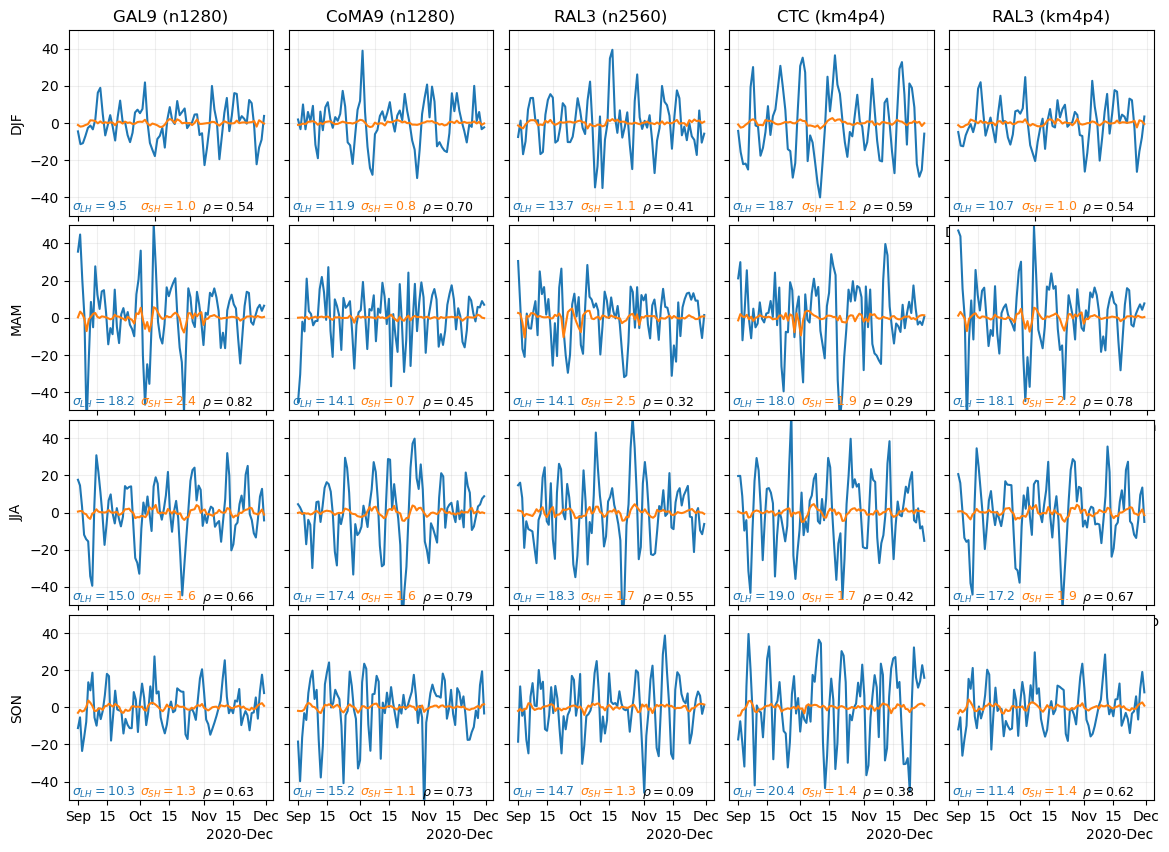

In [14]:
fig, ax = plt.subplots(ncols=ncols, nrows=4)

plt.subplots_adjust(wspace=0.075, hspace=0.05)

for i, (seas, mths) in enumerate(months_all.items()):
    lmonths = [imths[m] for m in mths]
    lmonths = list(itertools.chain(*lmonths))

    ax_ = ax[i]

    data_gal_lh_pt_ano_ = data_gal_lh_pt_ano.isel(time=lmonths)
    data_gal_sh_pt_ano_ = data_gal_sh_pt_ano.isel(time=lmonths)
    data_com_lh_pt_ano_ = data_com_lh_pt_ano.isel(time=lmonths)
    data_com_sh_pt_ano_ = data_com_sh_pt_ano.isel(time=lmonths)
    data_ral_lh_pt_ano_ = data_ral_lh_pt_ano.isel(time=lmonths)
    data_ral_sh_pt_ano_ = data_ral_sh_pt_ano.isel(time=lmonths)
    data_ctc_lh_pt_ano_ = data_ctc_lh_pt_ano.isel(time=lmonths)
    data_ctc_sh_pt_ano_ = data_ctc_sh_pt_ano.isel(time=lmonths)

    if region == 'Africa':
        data_lam_lh_pt_ano_ = data_lam_lh_pt_ano.isel(time=lmonths)
        data_lam_sh_pt_ano_ = data_lam_sh_pt_ano.isel(time=lmonths)
        pr_lam = pearsonr(data_lam_lh_pt_ano_, data_lam_sh_pt_ano_)
        rho_lam, pval_lam = pr_lam[0], pr_lam[1]
        data_lam_lh_pt_ano_.plot(ax=ax_[4])
        data_lam_sh_pt_ano_.plot(ax=ax_[4])
        ax_[4].text(0.015, 0.025, '$\\sigma_{LH}=%.1f$'%data_lam_lh_pt_ano_.std(), color=col_lh, fontsize=9, transform=ax_[4].transAxes)
        ax_[4].text(0.35, 0.025, '$\\sigma_{SH}=%.1f$'%data_lam_sh_pt_ano_.std(), color=col_sh, fontsize=9, transform=ax_[4].transAxes)
        ax_[4].text(0.65, 0.025, '$\\rho=%.2f$'%rho_lam, fontsize=9, transform=ax_[4].transAxes)
        ax_[4].set_xlabel('')
        ax_[4].set_ylim(ylims_ano)
        ax_[4].set_ylabel('')
        ax_[4].grid(True, alpha=0.2)
        ax_[4].set_yticklabels([])
        if i == 0:
            ax_[4].set_title('RAL3 (km4p4)')
        else:
            ax_[4].set_title('')

    pr_gal = pearsonr(data_gal_lh_pt_ano_, data_gal_sh_pt_ano_)
    rho_gal, pval_gal = pr_gal[0], pr_gal[1]
    pr_com = pearsonr(data_com_lh_pt_ano_, data_com_sh_pt_ano_)
    rho_com, pval_com = pr_com[0], pr_com[1]
    pr_ral = pearsonr(data_ral_lh_pt_ano_, data_ral_sh_pt_ano_)
    rho_ral, pval_ral = pr_ral[0], pr_ral[1]
    pr_ctc = pearsonr(data_ctc_lh_pt_ano_, data_ctc_sh_pt_ano_)
    rho_ctc, pval_ctc = pr_ctc[0], pr_ctc[1]


    data_gal_lh_pt_ano_.plot(ax=ax_[0])
    data_gal_sh_pt_ano_.plot(ax=ax_[0])
    data_com_lh_pt_ano_.plot(ax=ax_[1])
    data_com_sh_pt_ano_.plot(ax=ax_[1])
    data_ral_lh_pt_ano_.plot(ax=ax_[2])
    data_ral_sh_pt_ano_.plot(ax=ax_[2])
    data_ctc_lh_pt_ano_.plot(ax=ax_[3])
    data_ctc_sh_pt_ano_.plot(ax=ax_[3])

    ax_[0].text(0.015, 0.025, '$\\sigma_{LH}=%.1f$'%data_gal_lh_pt_ano_.std(), color=col_lh, fontsize=9, transform=ax_[0].transAxes)
    ax_[0].text(0.35, 0.025, '$\\sigma_{SH}=%.1f$'%data_gal_sh_pt_ano_.std(), color=col_sh, fontsize=9, transform=ax_[0].transAxes)
    ax_[0].text(0.65, 0.025, '$\\rho=%.2f$'%rho_gal, fontsize=9, transform=ax_[0].transAxes)
    ax_[1].text(0.015, 0.025, '$\\sigma_{LH}=%.1f$'%data_com_lh_pt_ano_.std(), color=col_lh, fontsize=9, transform=ax_[1].transAxes)
    ax_[1].text(0.35, 0.025, '$\\sigma_{SH}=%.1f$'%data_com_sh_pt_ano_.std(), color=col_sh, fontsize=9, transform=ax_[1].transAxes)
    ax_[1].text(0.65, 0.025, '$\\rho=%.2f$'%rho_com, fontsize=9, transform=ax_[1].transAxes)
    ax_[2].text(0.015, 0.025, '$\\sigma_{LH}=%.1f$'%data_ral_lh_pt_ano_.std(), color=col_lh, fontsize=9, transform=ax_[2].transAxes)
    ax_[2].text(0.35, 0.025, '$\\sigma_{SH}=%.1f$'%data_ral_sh_pt_ano_.std(), color=col_sh, fontsize=9, transform=ax_[2].transAxes)
    ax_[2].text(0.65, 0.025, '$\\rho=%.2f$'%rho_ral, fontsize=9, transform=ax_[2].transAxes)
    ax_[3].text(0.015, 0.025, '$\\sigma_{LH}=%.1f$'%data_ctc_lh_pt_ano_.std(), color=col_lh, fontsize=9, transform=ax_[3].transAxes)
    ax_[3].text(0.35, 0.025, '$\\sigma_{SH}=%.1f$'%data_ctc_sh_pt_ano_.std(), color=col_sh, fontsize=9, transform=ax_[3].transAxes)
    ax_[3].text(0.65, 0.025, '$\\rho=%.2f$'%rho_ctc, fontsize=9, transform=ax_[3].transAxes)

    if i != ax.shape[0]-1:
        ax_[0].set_xticklabels([])
        ax_[1].set_xticklabels([])
        ax_[2].set_xticklabels([])
        ax_[3].set_xticklabels([])
        #ax_[4].set_xticklabels([])

    ax_[0].set_xlabel('')
    ax_[1].set_xlabel('')
    ax_[2].set_xlabel('')
    ax_[3].set_xlabel('')

    ax_[0].set_ylim(ylims_ano)
    ax_[1].set_ylim(ylims_ano)
    ax_[2].set_ylim(ylims_ano)
    ax_[3].set_ylim(ylims_ano)

    ax_[0].set_ylabel(seas)
    ax_[1].set_ylabel('')
    ax_[2].set_ylabel('')
    ax_[3].set_ylabel('')

    ax_[0].grid(True, alpha=0.2)
    ax_[1].grid(True, alpha=0.2)
    ax_[2].grid(True, alpha=0.2)
    ax_[3].grid(True, alpha=0.2)

    ax_[1].set_yticklabels([])
    ax_[2].set_yticklabels([])
    ax_[3].set_yticklabels([])

    if i == 0:
        ax_[0].set_title('GAL9 (n1280)')
        ax_[1].set_title('CoMA9 (n1280)')
        ax_[2].set_title('RAL3 (n2560)')
        ax_[3].set_title('CTC (km4p4)')
    else:
        ax_[0].set_title('')
        ax_[1].set_title('')
        ax_[2].set_title('')
        ax_[3].set_title('')

fig.set_size_inches(14., 10.)

In [15]:
#~ Ocean masks

lats = data_gal_lh.lat.values
lons = data_gal_lh.lon.values
lons_, lats_ = np.meshgrid(lons, lats)
land_mask = is_land(lats_, lons_)

Temporal variability
-

LH max 81.959724
SH max 41.758236
LH max 66.13617
SH max 23.162712
LH max 70.98996
SH max 26.761282
LH max 64.153114
SH max 34.532787


/tmp/ipykernel_1694/1492941863.py:241: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 21 Axes> than <Figure size 640x480 with 16 Axes> which fig.colorbar is called on.
  cb = plt.colorbar(p_lh, ax=ax_lh[:], orientation='horizontal', label='$\\sigma_{LH}$ [W m-2]', shrink=0.5, pad=0.05)
/tmp/ipykernel_1694/1492941863.py:242: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 21 Axes> than <Figure size 640x480 with 16 Axes> which fig.colorbar is called on.
  plt.colorbar(p_sh, ax=ax_sh[:], orientation='horizontal', label='$\\sigma_{SH}$ [W m-2]', shrink=0.5, pad=0.05)
/tmp/ipykernel_1694/1492941863.py:243: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 17 Axes> than <Figure size 640x480 with 16 Axes> which fig.colorbar is called on.
  cb_diff = plt.colorbar(p_diff, ax=ax_diff_lh[:], orientation='horizontal', label='$\\Delta \\sigma_{LH}$ [W m-2]', shrink=0.5, pad=0.05)
/tmp/ipykernel_1694/1492941863.py:

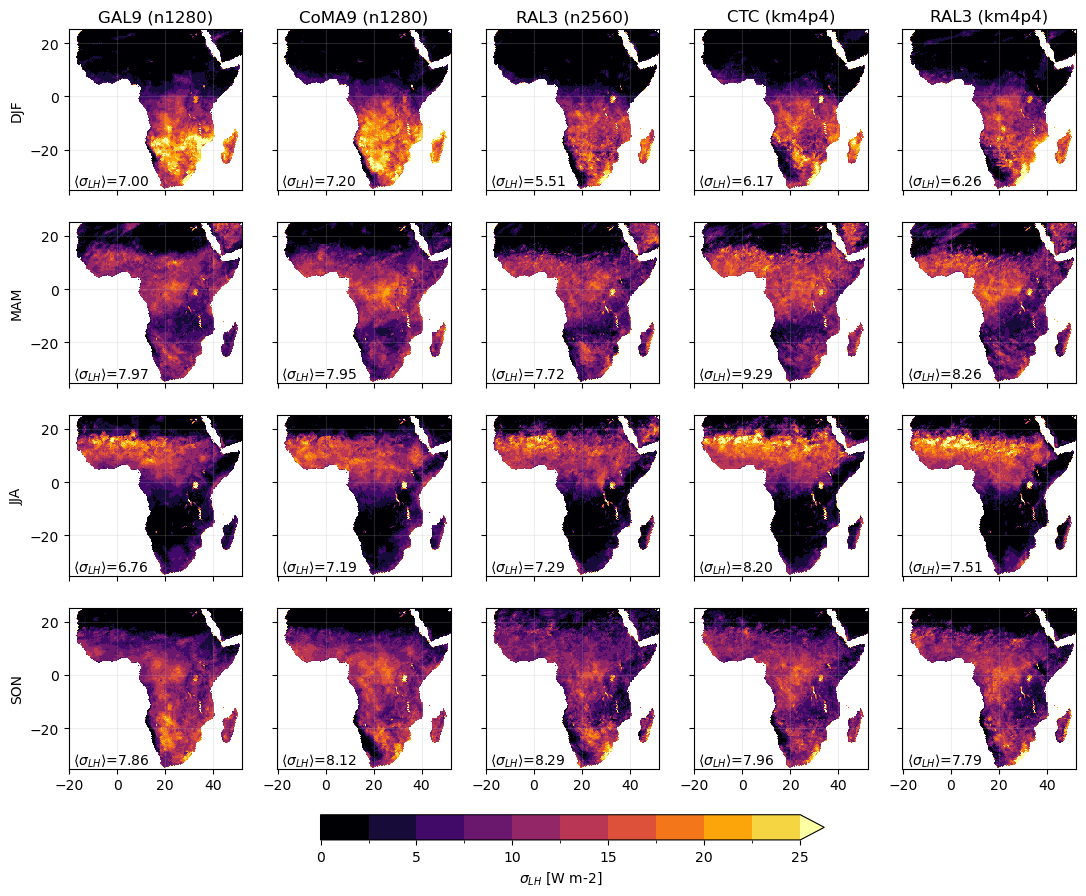

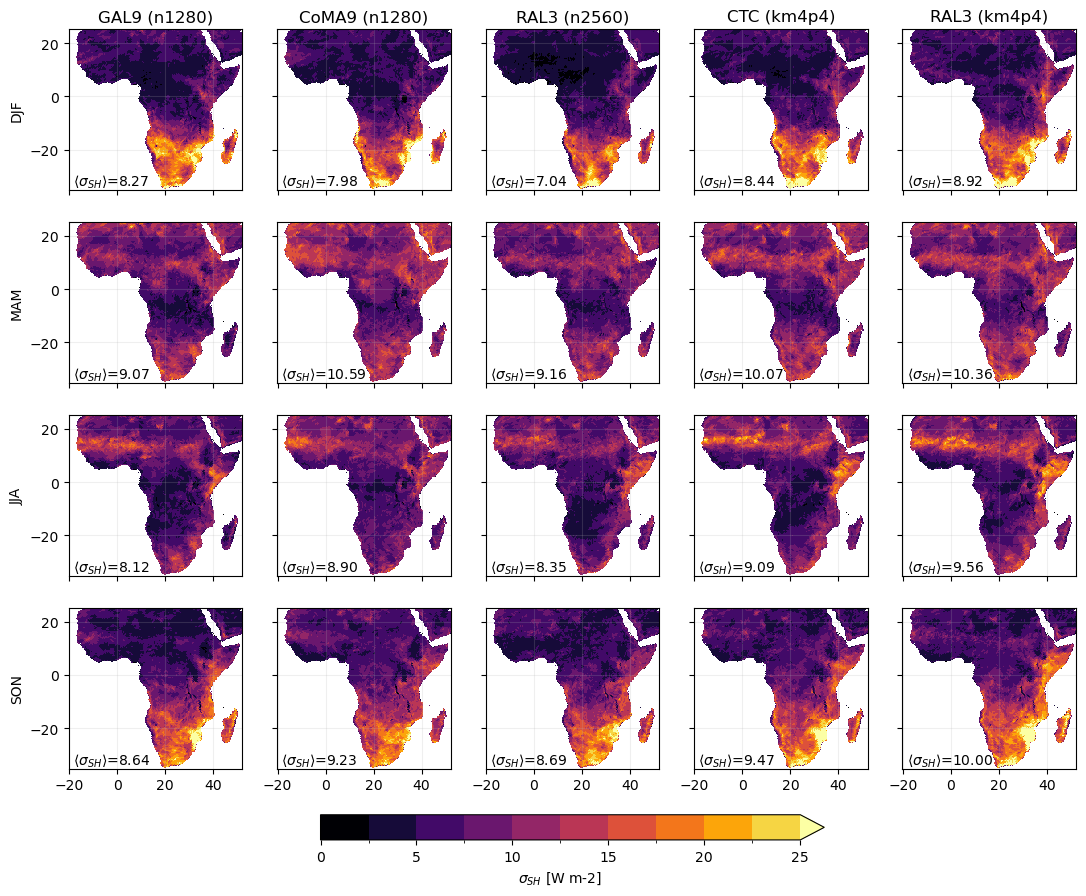

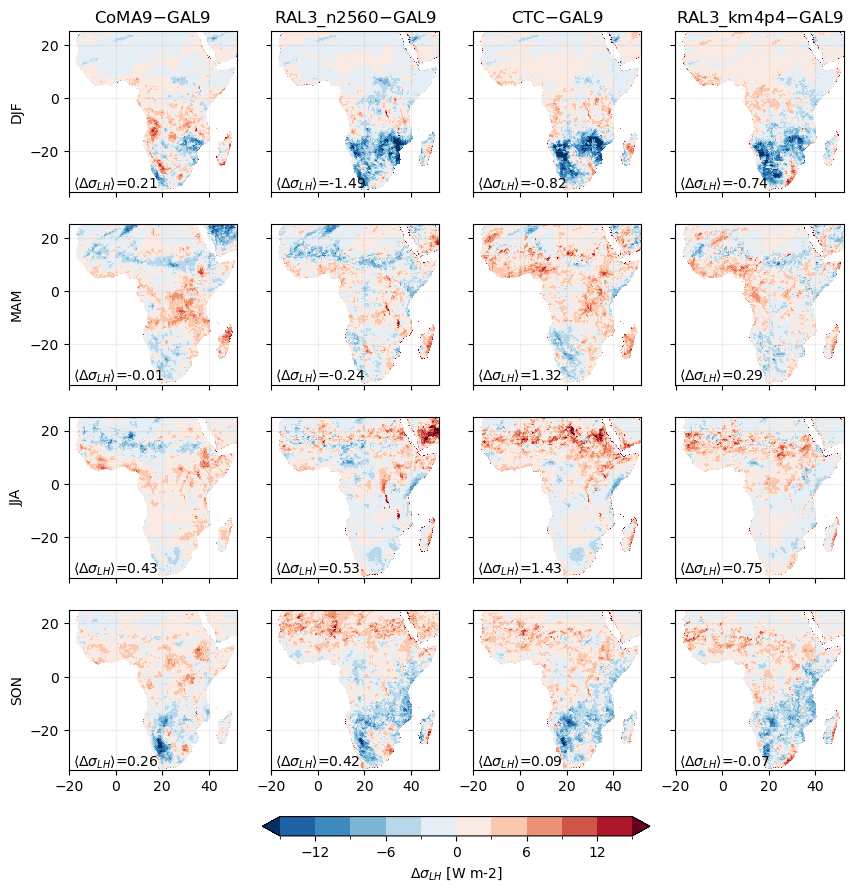

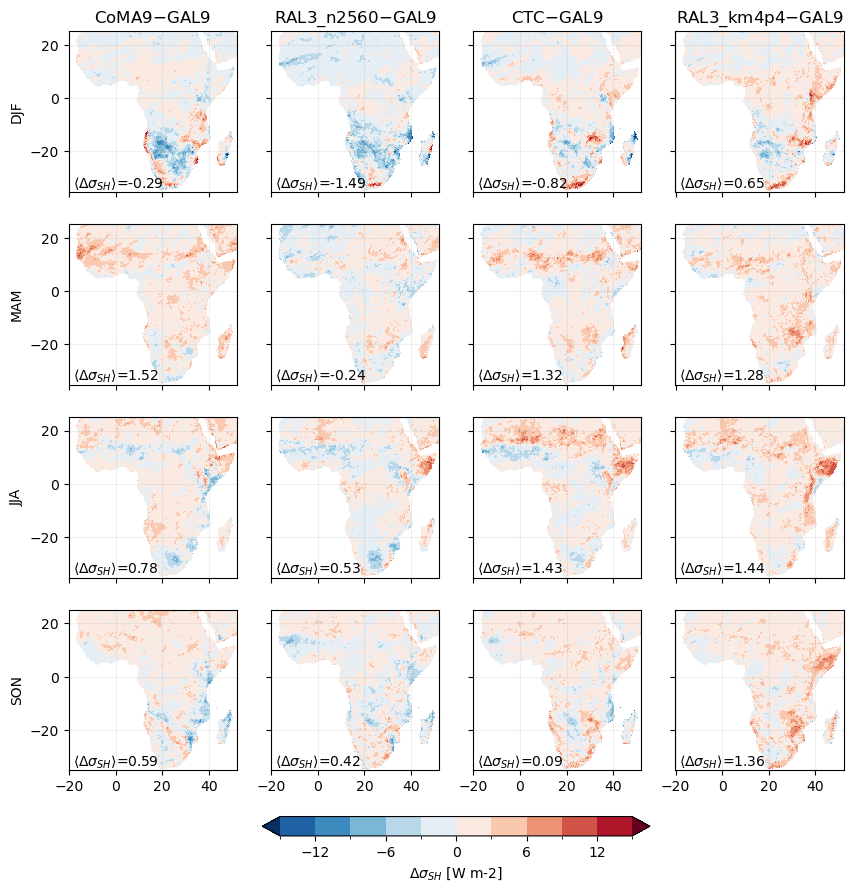

In [16]:
cmap = plt.get_cmap('inferno')
cmap_diff = plt.get_cmap('RdBu_r')

bounds_lh = np.linspace(0., 25., 11)
norm_lh = BoundaryNorm(bounds_lh, cmap.N, extend='max')
bounds_sh = np.linspace(0., 25., 11)
norm_sh = BoundaryNorm(bounds_sh, cmap.N, extend='max')
bounds_diff = np.linspace(-15, 15, 11)
norm_diff = BoundaryNorm(bounds_diff, cmap_diff.N, extend='both')

if region == 'Africa':
    ncols = 5
    ncols_diff = 4
else:
    ncols = 4
    ncols_diff = 3

fig_lh, ax_lh = plt.subplots(ncols=ncols, nrows=4)
fig_sh, ax_sh = plt.subplots(ncols=ncols, nrows=4)
fig_diff_lh, ax_diff_lh = plt.subplots(ncols=ncols_diff, nrows=4)
fig_diff_sh, ax_diff_sh = plt.subplots(ncols=ncols_diff, nrows=4)

for i, (seas, mths) in enumerate(months_all.items()):
    lmonths = [imths[m] for m in mths]
    lmonths = list(itertools.chain(*lmonths))

    ax_lh_ = ax_lh[i]
    ax_sh_ = ax_sh[i]
    ax_diff_lh_ = ax_diff_lh[i]
    ax_diff_sh_ = ax_diff_sh[i]

    data_gal_lh_ms = data_gal_lh_ano.isel(time=lmonths)
    data_gal_sh_ms = data_gal_sh_ano.isel(time=lmonths)
    data_com_lh_ms = data_com_lh_ano.isel(time=lmonths)
    data_com_sh_ms = data_com_sh_ano.isel(time=lmonths)
    data_ral_lh_ms = data_ral_lh_ano.isel(time=lmonths)
    data_ral_sh_ms = data_ral_sh_ano.isel(time=lmonths)
    data_ctc_lh_ms = data_ctc_lh_ano.isel(time=lmonths)
    data_ctc_sh_ms = data_ctc_sh_ano.isel(time=lmonths)

    lh_std_gal_ms = data_gal_lh_ms.std(dim='time')
    sh_std_gal_ms = data_gal_sh_ms.std(dim='time')
    lh_std_com_ms = data_com_lh_ms.std(dim='time')
    sh_std_com_ms = data_com_sh_ms.std(dim='time')
    lh_std_ral_ms = data_ral_lh_ms.std(dim='time')
    sh_std_ral_ms = data_ral_sh_ms.std(dim='time')
    lh_std_ctc_ms = data_ctc_lh_ms.std(dim='time')
    sh_std_ctc_ms = data_ctc_sh_ms.std(dim='time')

    if region == 'Africa':
        data_lam_lh_ms = data_lam_lh_ano.isel(time=lmonths)
        data_lam_sh_ms = data_lam_sh_ano.isel(time=lmonths)

        lh_std_lam_ms = data_lam_lh_ms.std(dim='time')
        sh_std_lam_ms = data_lam_sh_ms.std(dim='time')

        lh_std_lam_ms = ma.masked_array(lh_std_lam_ms, mask=~land_mask)
        lh_std_lam_ms_mean = np.nanmean(lh_std_lam_ms)
        sh_std_lam_ms = ma.masked_array(sh_std_lam_ms, mask=~land_mask)
        sh_std_lam_ms_mean = np.nanmean(sh_std_lam_ms)

        diff_lh_std_lam_ms = lh_std_lam_ms - lh_std_gal_ms
        diff_sh_std_lam_ms = sh_std_lam_ms - sh_std_gal_ms

        ax_lh_[4].pcolormesh(lons, lats, lh_std_lam_ms, norm=norm_lh, cmap=cmap)
        ax_sh_[4].pcolormesh(lons, lats, sh_std_lam_ms, norm=norm_sh, cmap=cmap)
        ax_lh_[4].text(0.025, 0.025, '$\\langle \\sigma_{LH} \\rangle$=%.2f'%lh_std_lam_ms_mean, transform=ax_lh_[4].transAxes)
        ax_sh_[4].text(0.025, 0.025, '$\\langle \\sigma_{SH} \\rangle$=%.2f'%sh_std_lam_ms_mean, transform=ax_sh_[4].transAxes)
        ax_lh_[4].grid(True, alpha=0.2)
        ax_sh_[4].grid(True, alpha=0.2)

        ax_diff_lh_[3].pcolormesh(lons, lats, diff_lh_std_lam_ms, norm=norm_diff, cmap=cmap_diff)
        ax_diff_sh_[3].pcolormesh(lons, lats, diff_sh_std_lam_ms, norm=norm_diff, cmap=cmap_diff)
        ax_diff_lh_[3].text(0.025, 0.025, '$\\langle \\Delta \\sigma_{LH} \\rangle$=%.2f'%diff_lh_std_lam_ms.mean(), transform=ax_diff_lh_[3].transAxes)
        ax_diff_sh_[3].text(0.025, 0.025, '$\\langle \\Delta \\sigma_{SH} \\rangle$=%.2f'%diff_sh_std_lam_ms.mean(), transform=ax_diff_sh_[3].transAxes)
        ax_diff_lh_[3].grid(True, alpha=0.2)
        ax_diff_sh_[3].grid(True, alpha=0.2)

    lh_std_gal_ms = ma.masked_array(lh_std_gal_ms, mask=~land_mask)
    sh_std_gal_ms = ma.masked_array(sh_std_gal_ms, mask=~land_mask)
    lh_std_com_ms = ma.masked_array(lh_std_com_ms, mask=~land_mask)
    sh_std_com_ms = ma.masked_array(sh_std_com_ms, mask=~land_mask)
    lh_std_ral_ms = ma.masked_array(lh_std_ral_ms, mask=~land_mask)
    sh_std_ral_ms = ma.masked_array(sh_std_ral_ms, mask=~land_mask)
    lh_std_ctc_ms = ma.masked_array(lh_std_ctc_ms, mask=~land_mask)
    sh_std_ctc_ms = ma.masked_array(sh_std_ctc_ms, mask=~land_mask)

    diff_lh_std_com_ms = lh_std_com_ms - lh_std_gal_ms
    diff_sh_std_com_ms = sh_std_com_ms - sh_std_gal_ms
    diff_lh_std_ral_ms = lh_std_ral_ms - lh_std_gal_ms
    diff_sh_std_ral_ms = sh_std_ral_ms - sh_std_gal_ms
    diff_lh_std_ctc_ms = lh_std_ctc_ms - lh_std_gal_ms
    diff_sh_std_ctc_ms = sh_std_ctc_ms - sh_std_gal_ms

    print('LH max', max(abs(lh_std_gal_ms.max()), abs(lh_std_ral_ms.max()), abs(lh_std_ctc_ms.max())))  #, abs(lh_std_lam_ms.max())))
    print('SH max', max(abs(sh_std_gal_ms.max()), abs(sh_std_ral_ms.max()), abs(sh_std_ctc_ms.max())))  #, abs(sh_std_lam_ms.max())))

    lh_std_gal_ms_mean = np.nanmean(lh_std_gal_ms)
    sh_std_gal_ms_mean = np.nanmean(sh_std_gal_ms)
    lh_std_com_ms_mean = np.nanmean(lh_std_com_ms)
    sh_std_com_ms_mean = np.nanmean(sh_std_com_ms)
    lh_std_ral_ms_mean = np.nanmean(lh_std_ral_ms)
    sh_std_ral_ms_mean = np.nanmean(sh_std_ral_ms)
    lh_std_ctc_ms_mean = np.nanmean(lh_std_ctc_ms)
    sh_std_ctc_ms_mean = np.nanmean(sh_std_ctc_ms)


    p_lh = ax_lh_[0].pcolormesh(lons, lats, lh_std_gal_ms, norm=norm_lh, cmap=cmap)
    p_sh = ax_sh_[0].pcolormesh(lons, lats, sh_std_gal_ms, norm=norm_sh, cmap=cmap)
    ax_lh_[1].pcolormesh(lons, lats, lh_std_com_ms, norm=norm_lh, cmap=cmap)
    ax_sh_[1].pcolormesh(lons, lats, sh_std_com_ms, norm=norm_sh, cmap=cmap)
    ax_lh_[2].pcolormesh(lons, lats, lh_std_ral_ms, norm=norm_lh, cmap=cmap)
    ax_sh_[2].pcolormesh(lons, lats, sh_std_ral_ms, norm=norm_sh, cmap=cmap)
    ax_lh_[3].pcolormesh(lons, lats, lh_std_ctc_ms, norm=norm_lh, cmap=cmap)
    ax_sh_[3].pcolormesh(lons, lats, sh_std_ctc_ms, norm=norm_sh, cmap=cmap)

    p_diff = ax_diff_lh_[0].pcolormesh(lons, lats, diff_lh_std_com_ms, norm=norm_diff, cmap=cmap_diff)
    ax_diff_sh_[0].pcolormesh(lons, lats, diff_sh_std_com_ms, norm=norm_diff, cmap=cmap_diff)
    ax_diff_lh_[1].pcolormesh(lons, lats, diff_lh_std_ral_ms, norm=norm_diff, cmap=cmap_diff)
    ax_diff_sh_[1].pcolormesh(lons, lats, diff_sh_std_ral_ms, norm=norm_diff, cmap=cmap_diff)
    ax_diff_lh_[2].pcolormesh(lons, lats, diff_lh_std_ctc_ms, norm=norm_diff, cmap=cmap_diff)
    ax_diff_sh_[2].pcolormesh(lons, lats, diff_sh_std_ctc_ms, norm=norm_diff, cmap=cmap_diff)

    if (region == 'Africa') or (region == 'SEA'):
        ax_lh_[0].text(0.025, 0.025, '$\\langle \\sigma_{LH} \\rangle$=%.2f'%lh_std_gal_ms.mean(), transform=ax_lh_[0].transAxes)
        ax_sh_[0].text(0.025, 0.025, '$\\langle \\sigma_{SH} \\rangle$=%.2f'%sh_std_gal_ms.mean(), transform=ax_sh_[0].transAxes)
        ax_lh_[1].text(0.025, 0.025, '$\\langle \\sigma_{LH} \\rangle$=%.2f'%lh_std_com_ms.mean(), transform=ax_lh_[1].transAxes)
        ax_sh_[1].text(0.025, 0.025, '$\\langle \\sigma_{SH} \\rangle$=%.2f'%sh_std_com_ms.mean(), transform=ax_sh_[1].transAxes)
        ax_lh_[2].text(0.025, 0.025, '$\\langle \\sigma_{LH} \\rangle$=%.2f'%lh_std_ral_ms.mean(), transform=ax_lh_[2].transAxes)
        ax_sh_[2].text(0.025, 0.025, '$\\langle \\sigma_{SH} \\rangle$=%.2f'%sh_std_ral_ms.mean(), transform=ax_sh_[2].transAxes)
        ax_lh_[3].text(0.025, 0.025, '$\\langle \\sigma_{LH} \\rangle$=%.2f'%lh_std_ctc_ms.mean(), transform=ax_lh_[3].transAxes)
        ax_sh_[3].text(0.025, 0.025, '$\\langle \\sigma_{SH} \\rangle$=%.2f'%sh_std_ctc_ms.mean(), transform=ax_sh_[3].transAxes)
        ax_diff_lh_[0].text(0.025, 0.025, '$\\langle \\Delta \\sigma_{LH} \\rangle$=%.2f'%diff_lh_std_com_ms.mean(), transform=ax_diff_lh_[0].transAxes)
        ax_diff_sh_[0].text(0.025, 0.025, '$\\langle \\Delta \\sigma_{SH} \\rangle$=%.2f'%diff_sh_std_com_ms.mean(), transform=ax_diff_sh_[0].transAxes)
        ax_diff_lh_[1].text(0.025, 0.025, '$\\langle \\Delta \\sigma_{LH} \\rangle$=%.2f'%diff_lh_std_ral_ms.mean(), transform=ax_diff_lh_[1].transAxes)
        ax_diff_sh_[1].text(0.025, 0.025, '$\\langle \\Delta \\sigma_{SH} \\rangle$=%.2f'%diff_lh_std_ral_ms.mean(), transform=ax_diff_sh_[1].transAxes)
        ax_diff_lh_[2].text(0.025, 0.025, '$\\langle \\Delta \\sigma_{LH} \\rangle$=%.2f'%diff_lh_std_ctc_ms.mean(), transform=ax_diff_lh_[2].transAxes)
        ax_diff_sh_[2].text(0.025, 0.025, '$\\langle \\Delta \\sigma_{SH} \\rangle$=%.2f'%diff_lh_std_ctc_ms.mean(), transform=ax_diff_sh_[2].transAxes)
    elif region == 'SAmer':
        ax_lh_[0].text(0.55, 0.92, '$\\langle \\sigma_{LH} \\rangle$=%.2f'%lh_std_gal_ms_mean, transform=ax_lh_[0].transAxes)
        ax_sh_[0].text(0.55, 0.92, '$\\langle \\sigma_{SH} \\rangle$=%.2f'%sh_std_gal_ms_mean, transform=ax_sh_[0].transAxes)
        ax_lh_[1].text(0.55, 0.92, '$\\langle \\sigma_{LH} \\rangle$=%.2f'%lh_std_com_ms_mean, transform=ax_lh_[1].transAxes)
        ax_sh_[1].text(0.55, 0.92, '$\\langle \\sigma_{SH} \\rangle$=%.2f'%sh_std_com_ms_mean, transform=ax_sh_[1].transAxes)
        ax_lh_[2].text(0.55, 0.92, '$\\langle \\sigma_{LH} \\rangle$=%.2f'%lh_std_ral_ms_mean, transform=ax_lh_[2].transAxes)
        ax_sh_[2].text(0.55, 0.92, '$\\langle \\sigma_{SH} \\rangle$=%.2f'%sh_std_ral_ms_mean, transform=ax_sh_[2].transAxes)
        ax_lh_[3].text(0.55, 0.92, '$\\langle \\sigma_{LH} \\rangle$=%.2f'%lh_std_ctc_ms_mean, transform=ax_lh_[3].transAxes)
        ax_sh_[3].text(0.55, 0.92, '$\\langle \\sigma_{SH} \\rangle$=%.2f'%sh_std_ctc_ms_mean, transform=ax_sh_[3].transAxes)
        ax_diff_lh_[0].text(0.55, 0.92, '$\\langle \\Delta \\sigma_{LH} \\rangle$=%.2f'%diff_lh_std_com_ms.mean(), transform=ax_diff_lh_[0].transAxes)
        ax_diff_sh_[0].text(0.55, 0.92, '$\\langle \\Delta \\sigma_{SH} \\rangle$=%.2f'%diff_sh_std_com_ms.mean(), transform=ax_diff_sh_[0].transAxes)
        ax_diff_lh_[1].text(0.55, 0.92, '$\\langle \\Delta \\sigma_{LH} \\rangle$=%.2f'%diff_lh_std_ral_ms.mean(), transform=ax_diff_lh_[1].transAxes)
        ax_diff_sh_[1].text(0.55, 0.92, '$\\langle \\Delta \\sigma_{SH} \\rangle$=%.2f'%diff_sh_std_ral_ms.mean(), transform=ax_diff_sh_[1].transAxes)
        ax_diff_lh_[2].text(0.55, 0.92, '$\\langle \\Delta \\sigma_{LH} \\rangle$=%.2f'%diff_lh_std_ctc_ms.mean(), transform=ax_diff_lh_[2].transAxes)
        ax_diff_sh_[2].text(0.55, 0.92, '$\\langle \\Delta \\sigma_{SH} \\rangle$=%.2f'%diff_sh_std_ctc_ms.mean(), transform=ax_diff_sh_[2].transAxes)

    ax_lh_[0].set_ylabel(seas)
    ax_lh_[0].grid(True, alpha=0.2)
    ax_lh_[1].grid(True, alpha=0.2)
    ax_lh_[2].grid(True, alpha=0.2)
    ax_lh_[3].grid(True, alpha=0.2)
    ax_sh_[0].set_ylabel(seas)
    ax_sh_[0].grid(True, alpha=0.2)
    ax_sh_[1].grid(True, alpha=0.2)
    ax_sh_[2].grid(True, alpha=0.2)
    ax_sh_[3].grid(True, alpha=0.2)
    ax_diff_lh_[0].set_ylabel(seas)
    ax_diff_lh_[0].grid(True, alpha=0.2)
    ax_diff_lh_[1].grid(True, alpha=0.2)
    ax_diff_sh_[0].set_ylabel(seas)
    ax_diff_sh_[0].grid(True, alpha=0.2)
    ax_diff_sh_[1].grid(True, alpha=0.2)
    if region == 'Africa':
        ax_lh_[4].set_yticklabels([])
        ax_sh_[4].set_yticklabels([])
        ax_diff_lh_[2].grid(True, alpha=0.2)
        ax_diff_sh_[2].grid(True, alpha=0.2)
        ax_diff_lh_[3].set_yticklabels([])
        ax_diff_sh_[3].set_yticklabels([])

    ax_lh_[1].set_yticklabels([])
    ax_lh_[2].set_yticklabels([])
    ax_lh_[3].set_yticklabels([])
    ax_sh_[1].set_yticklabels([])
    ax_sh_[2].set_yticklabels([])
    ax_sh_[3].set_yticklabels([])
    ax_diff_lh_[1].set_yticklabels([])
    ax_diff_lh_[2].set_yticklabels([])
    ax_diff_sh_[1].set_yticklabels([])
    ax_diff_sh_[2].set_yticklabels([])

    if i == 0:
        ax_lh_[0].set_title('GAL9 (n1280)')
        ax_lh_[1].set_title('CoMA9 (n1280)')
        ax_lh_[2].set_title('RAL3 (n2560)')
        ax_lh_[3].set_title('CTC (km4p4)')
        ax_sh_[0].set_title('GAL9 (n1280)')
        ax_sh_[1].set_title('CoMA9 (n1280)')
        ax_sh_[2].set_title('RAL3 (n2560)')
        ax_sh_[3].set_title('CTC (km4p4)')
        ax_diff_lh_[0].set_title('CoMA9$-$GAL9')
        ax_diff_lh_[1].set_title('RAL3_n2560$-$GAL9')
        ax_diff_lh_[2].set_title('CTC$-$GAL9')
        ax_diff_sh_[0].set_title('CoMA9$-$GAL9')
        ax_diff_sh_[1].set_title('RAL3_n2560$-$GAL9')
        ax_diff_sh_[2].set_title('CTC$-$GAL9')
        if region == 'Africa':
            ax_lh_[4].set_title('RAL3 (km4p4)')
            ax_sh_[4].set_title('RAL3 (km4p4)')
            ax_diff_lh_[3].set_title('RAL3_km4p4$-$GAL9')
            ax_diff_sh_[3].set_title('RAL3_km4p4$-$GAL9')
    else:
        ax_lh_[0].set_title('')
        ax_lh_[1].set_title('')
        ax_sh_[0].set_title('')
        ax_sh_[1].set_title('')
        if region == 'Africa':
            ax_lh_[2].set_title('')
            ax_sh_[2].set_title('')
        #ax_[3].set_title('')

    if i != 3:
        ax_lh_[0].set_xticklabels([])
        ax_lh_[1].set_xticklabels([])
        ax_lh_[2].set_xticklabels([])
        ax_lh_[3].set_xticklabels([])
        ax_sh_[0].set_xticklabels([])
        ax_sh_[1].set_xticklabels([])
        ax_sh_[2].set_xticklabels([])
        ax_sh_[3].set_xticklabels([])
        ax_diff_lh_[0].set_xticklabels([])
        ax_diff_lh_[1].set_xticklabels([])
        ax_diff_lh_[2].set_xticklabels([])
        ax_diff_sh_[0].set_xticklabels([])
        ax_diff_sh_[1].set_xticklabels([])
        ax_diff_sh_[2].set_xticklabels([])
        if region == 'Africa':
            ax_lh_[4].set_xticklabels([])
            ax_sh_[4].set_xticklabels([])
            ax_diff_lh_[3].set_xticklabels([])
            ax_diff_sh_[3].set_xticklabels([])

cb = plt.colorbar(p_lh, ax=ax_lh[:], orientation='horizontal', label='$\\sigma_{LH}$ [W m-2]', shrink=0.5, pad=0.05)
plt.colorbar(p_sh, ax=ax_sh[:], orientation='horizontal', label='$\\sigma_{SH}$ [W m-2]', shrink=0.5, pad=0.05)
cb_diff = plt.colorbar(p_diff, ax=ax_diff_lh[:], orientation='horizontal', label='$\\Delta \\sigma_{LH}$ [W m-2]', shrink=0.5, pad=0.05)
plt.colorbar(p_diff, ax=ax_diff_sh[:], orientation='horizontal', label='$\\Delta \\sigma_{SH}$ [W m-2]', shrink=0.5, pad=0.05)

fig_lh.set_size_inches(13., 12.)
fig_sh.set_size_inches(13., 12.)
fig_diff_lh.set_size_inches(10., 12.)
fig_diff_sh.set_size_inches(10., 12.)

Spatial variability
-

0


/tmp/ipykernel_1694/521947954.py:188: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 16 Axes> than <Figure size 640x480 with 15 Axes> which fig.colorbar is called on.
  cb = plt.colorbar(p_map_lh, ax=ax_map_lh[i,:], orientation='vertical', label='$\\nabla_y$LH [W m$^{-2}$ km$^{-1}$]', shrink=1., pad=0.01)


GAL9 -2.328570911619399 1.7045646588007615
CoM -4.158366584777833 2.7068970097435856
RAL -7.247056007385257 2.6623502519395625
CTC -3.175862169265748 2.067327880859376
LAM -3.2854086505042193 2.085481664869521
1


/tmp/ipykernel_1694/521947954.py:188: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 17 Axes> than <Figure size 640x480 with 16 Axes> which fig.colorbar is called on.
  cb = plt.colorbar(p_map_lh, ax=ax_map_lh[i,:], orientation='vertical', label='$\\nabla_y$LH [W m$^{-2}$ km$^{-1}$]', shrink=1., pad=0.01)


GAL9 -0.09314283874299793 0.06818258749114145
CoM -0.16633466111289136 0.14098175260755755
RAL -0.2898822402954102 0.10649400552113854
CTC -0.1270344890488519 0.08269311295615304
LAM -0.1314163414637248 0.08341926773389183
2


/tmp/ipykernel_1694/521947954.py:188: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 18 Axes> than <Figure size 640x480 with 17 Axes> which fig.colorbar is called on.
  cb = plt.colorbar(p_map_lh, ax=ax_map_lh[i,:], orientation='vertical', label='$\\nabla_y$LH [W m$^{-2}$ km$^{-1}$]', shrink=1., pad=0.01)


GAL9 -0.019244388287717653 0.014087311818142136
CoM -0.03436666528383892 0.029128460811846196
RAL -0.05989302673725169 0.022002894408775106
CTC -0.026246794787320234 0.017085354857974588
LAM -0.02715213690141236 0.017235386130785707


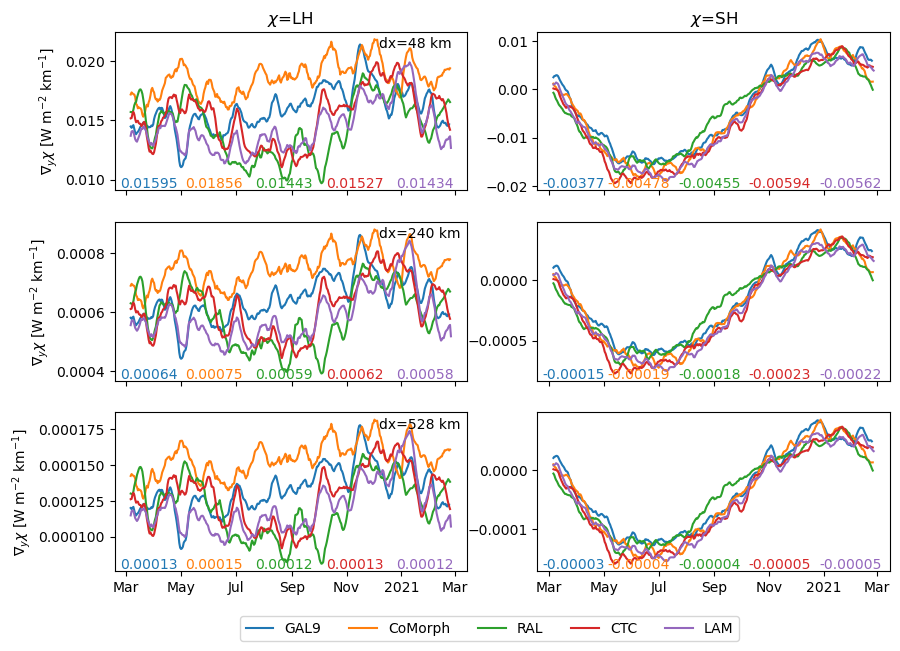

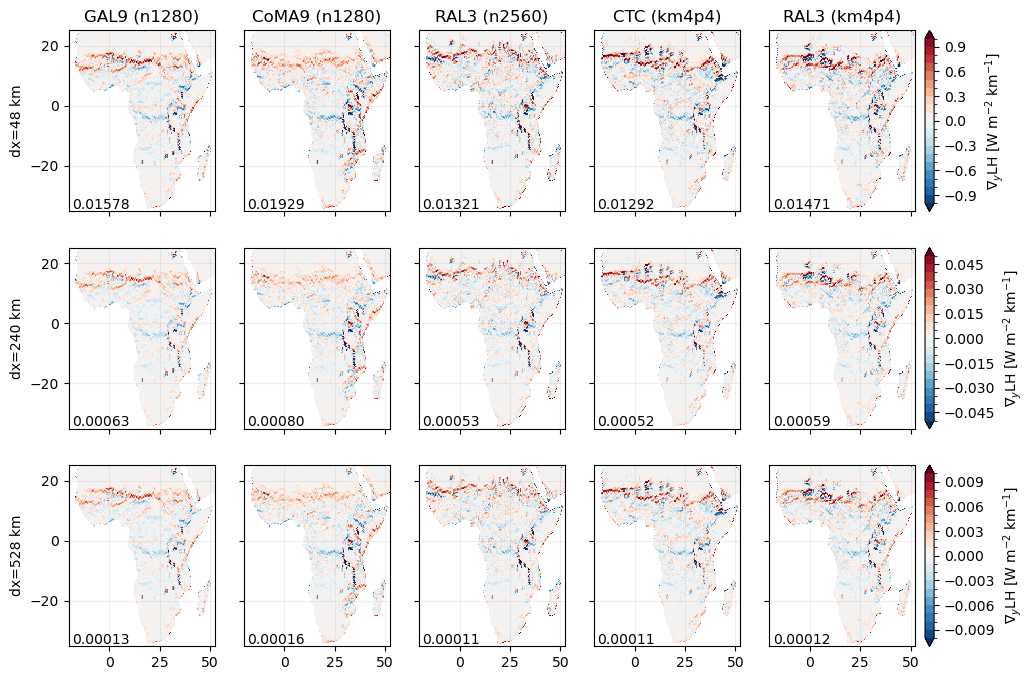

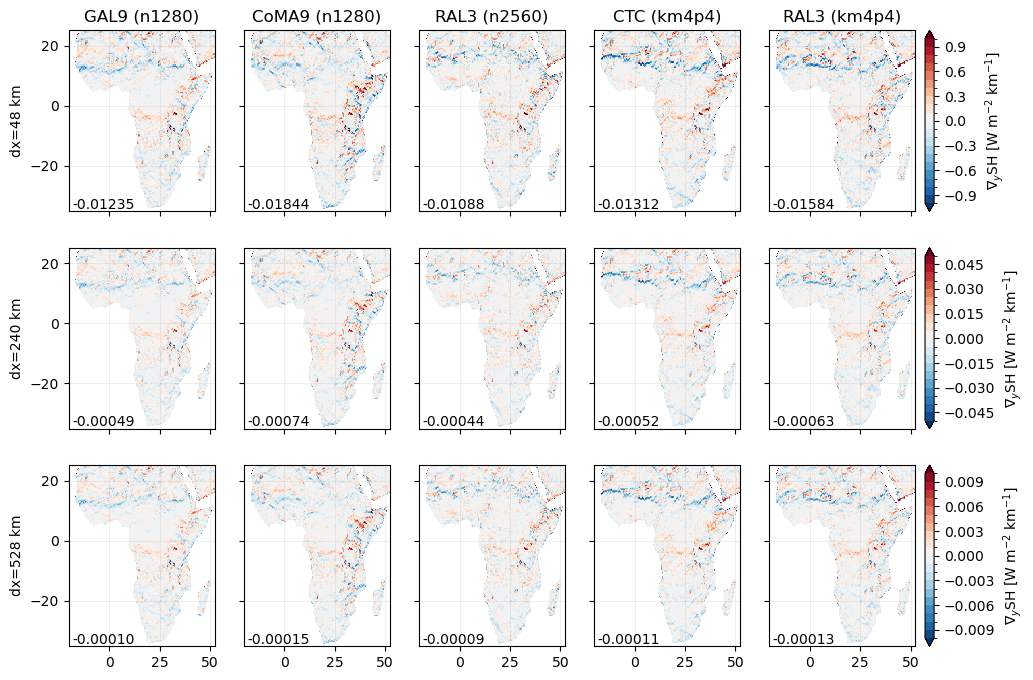

In [17]:
ylims = (4., 16.)
day = 150

cmap = plt.get_cmap('RdBu_r')  # inferno_r

bounds = np.linspace(-40, 40, 11)
norm = BoundaryNorm(bounds, cmap.N, extend='both')

fig, ax = plt.subplots(nrows=3, ncols=2)
fig_map_lh, ax_map_lh = plt.subplots(nrows=3, ncols=ncols)
fig_map_sh, ax_map_sh = plt.subplots(nrows=3, ncols=ncols)

grid_step = [1, 5, 11]
clims = [1., 0.05, 0.01]

for i, gs in enumerate(grid_step):
    print(i)

    data_gal_lh = data_gal_lh.where(land_mask)
    data_gal_sh = data_gal_sh.where(land_mask)
    data_com_lh = data_com_lh.where(land_mask)
    data_com_sh = data_com_sh.where(land_mask)
    data_ral_lh = data_ral_lh.where(land_mask)
    data_ral_sh = data_ral_sh.where(land_mask)
    data_ctc_lh = data_ctc_lh.where(land_mask)
    data_ctc_sh = data_ctc_sh.where(land_mask)
    data_lam_lh = data_lam_lh.where(land_mask)
    data_lam_sh = data_lam_sh.where(land_mask)

    #~ Get gradient
    grads_gal_lh = np.gradient(data_gal_lh, gs, axis=[1, 2])
    grads_gal_sh = np.gradient(data_gal_sh, gs, axis=[1, 2])
    grads_com_lh = np.gradient(data_com_lh, gs, axis=[1, 2])
    grads_com_sh = np.gradient(data_com_sh, gs, axis=[1, 2])
    grads_ral_lh = np.gradient(data_ral_lh, gs, axis=[1, 2])
    grads_ral_sh = np.gradient(data_ral_sh, gs, axis=[1, 2])
    grads_ctc_lh = np.gradient(data_ctc_lh, gs, axis=[1, 2])
    grads_ctc_sh = np.gradient(data_ctc_sh, gs, axis=[1, 2])
    grads_lam_lh = np.gradient(data_lam_lh, gs, axis=[1, 2])
    grads_lam_sh = np.gradient(data_lam_sh, gs, axis=[1, 2])
    
    gradmer_gal_lh = xr.DataArray(grads_gal_lh[0], coords=data_gal_lh.coords)
    gradmer_gal_sh = xr.DataArray(grads_gal_sh[0], coords=data_gal_sh.coords)
    gradmer_com_lh = xr.DataArray(grads_com_lh[0], coords=data_com_lh.coords)
    gradmer_com_sh = xr.DataArray(grads_com_sh[0], coords=data_com_sh.coords)
    gradmer_ral_lh = xr.DataArray(grads_ral_lh[0], coords=data_ral_lh.coords)
    gradmer_ral_sh = xr.DataArray(grads_ral_sh[0], coords=data_ral_sh.coords)
    gradmer_ctc_lh = xr.DataArray(grads_ctc_lh[0], coords=data_ctc_lh.coords)
    gradmer_ctc_sh = xr.DataArray(grads_ctc_sh[0], coords=data_ctc_sh.coords)
    gradmer_lam_lh = xr.DataArray(grads_lam_lh[0], coords=data_lam_lh.coords)
    gradmer_lam_sh = xr.DataArray(grads_lam_sh[0], coords=data_lam_sh.coords)

    gradmer_gal_lh = gradmer_gal_lh.where(abs(gradmer_gal_lh < 100))  / (gs*dx) # where(land_mask)
    gradmer_gal_sh = gradmer_gal_sh.where(abs(gradmer_gal_sh < 100))  / (gs*dx) # where(land_mask)
    gradmer_com_lh = gradmer_com_lh.where(abs(gradmer_com_lh < 100))  / (gs*dx) # where(land_mask)
    gradmer_com_sh = gradmer_com_sh.where(abs(gradmer_com_sh < 100))  / (gs*dx) # where(land_mask)
    gradmer_ral_lh = gradmer_ral_lh.where(abs(gradmer_ral_lh < 100))  / (gs*dx) # where(land_mask)
    gradmer_ral_sh = gradmer_ral_sh.where(abs(gradmer_ral_sh < 100))  / (gs*dx) # where(land_mask)
    gradmer_ctc_lh = gradmer_ctc_lh.where(abs(gradmer_ctc_lh < 100))  / (gs*dx) # where(land_mask)
    gradmer_ctc_sh = gradmer_ctc_sh.where(abs(gradmer_ctc_sh < 100))  / (gs*dx) # where(land_mask)
    gradmer_lam_lh = gradmer_lam_lh.where(abs(gradmer_lam_lh < 100))  / (gs*dx) # where(land_mask)
    gradmer_lam_sh = gradmer_lam_sh.where(abs(gradmer_lam_sh < 100))  / (gs*dx) # where(land_mask)

    #~ Get laplacian
    lap_gal_lh = np.gradient(grads_gal_lh[0], axis=[1,2])[0] + np.gradient(grads_gal_lh[1], axis=[1,2])[1]
    lap_gal_sh = np.gradient(grads_gal_sh[0], axis=[1,2])[0] + np.gradient(grads_gal_sh[1], axis=[1,2])[1]
    lap_com_lh = np.gradient(grads_com_lh[0], axis=[1,2])[0] + np.gradient(grads_com_lh[1], axis=[1,2])[1]
    lap_com_sh = np.gradient(grads_com_sh[0], axis=[1,2])[0] + np.gradient(grads_com_sh[1], axis=[1,2])[1]
    lap_ral_lh = np.gradient(grads_ral_lh[0], axis=[1,2])[0] + np.gradient(grads_ral_lh[1], axis=[1,2])[1]
    lap_ral_sh = np.gradient(grads_ral_sh[0], axis=[1,2])[0] + np.gradient(grads_ral_sh[1], axis=[1,2])[1]
    lap_ctc_lh = np.gradient(grads_ctc_lh[0], axis=[1,2])[0] + np.gradient(grads_ctc_lh[1], axis=[1,2])[1]
    lap_ctc_sh = np.gradient(grads_ctc_sh[0], axis=[1,2])[0] + np.gradient(grads_ctc_sh[1], axis=[1,2])[1]
    lap_lam_lh = np.gradient(grads_lam_lh[0], axis=[1,2])[0] + np.gradient(grads_lam_lh[1], axis=[1,2])[1]
    lap_lam_sh = np.gradient(grads_lam_sh[0], axis=[1,2])[0] + np.gradient(grads_lam_sh[1], axis=[1,2])[1]

    lap_gal_lh = xr.DataArray(lap_gal_lh, coords=data_gal_lh.coords)
    lap_gal_sh = xr.DataArray(lap_gal_sh, coords=data_gal_sh.coords)
    lap_com_lh = xr.DataArray(lap_com_lh, coords=data_com_lh.coords)
    lap_com_sh = xr.DataArray(lap_com_sh, coords=data_com_sh.coords)
    lap_ral_lh = xr.DataArray(lap_ral_lh, coords=data_ral_lh.coords)
    lap_ral_sh = xr.DataArray(lap_ral_sh, coords=data_ral_sh.coords)
    lap_ctc_lh = xr.DataArray(lap_ctc_lh, coords=data_ctc_lh.coords)
    lap_ctc_sh = xr.DataArray(lap_ctc_sh, coords=data_ctc_sh.coords)
    lap_lam_lh = xr.DataArray(lap_lam_lh, coords=data_lam_lh.coords)
    lap_lam_sh = xr.DataArray(lap_lam_sh, coords=data_lam_sh.coords)

    """gradmer_gal_lh = abs(lap_gal_lh.where(abs(lap_gal_lh) < 100)).where(land_mask)
    gradmer_gal_sh = abs(lap_gal_sh.where(abs(lap_gal_sh) < 100)).where(land_mask)
    gradmer_com_lh = abs(lap_com_lh.where(abs(lap_com_lh) < 100)).where(land_mask)
    gradmer_com_sh = abs(lap_com_sh.where(abs(lap_com_sh) < 100)).where(land_mask)
    gradmer_ral_lh = abs(lap_ral_lh.where(abs(lap_ral_lh) < 100)).where(land_mask)
    gradmer_ral_sh = abs(lap_ral_sh.where(abs(lap_ral_sh) < 100)).where(land_mask)
    gradmer_ctc_lh = abs(lap_ctc_lh.where(abs(lap_ctc_lh) < 100)).where(land_mask)
    gradmer_ctc_sh = abs(lap_ctc_sh.where(abs(lap_ctc_sh) < 100)).where(land_mask)
    gradmer_lam_lh = abs(lap_lam_lh.where(abs(lap_lam_lh) < 100)).where(land_mask)
    gradmer_lam_sh = abs(lap_lam_sh.where(abs(lap_lam_sh) < 100)).where(land_mask)"""

    clim_lh = clims[i] #1
    """max(abs(gradmer_gal_lh.isel(time=day).min().values), gradmer_gal_lh.isel(time=day).max().values,
        abs(gradmer_com_lh.isel(time=day).min().values), gradmer_com_lh.isel(time=day).max().values,
        abs(gradmer_ral_lh.isel(time=day).min().values), gradmer_ral_lh.isel(time=day).max().values,
        abs(gradmer_ctc_lh.isel(time=day).min().values), gradmer_ctc_lh.isel(time=day).max().values,
        abs(gradmer_lam_lh.isel(time=day).min().values), gradmer_lam_lh.isel(time=day).max().values)"""
    clim_sh = clims[i] #0.25
    """max(abs(gradmer_gal_sh.isel(time=day).min().values), gradmer_gal_sh.isel(time=day).max().values,
        abs(gradmer_com_sh.isel(time=day).min().values), gradmer_com_sh.isel(time=day).max().values,
        abs(gradmer_ral_sh.isel(time=day).min().values), gradmer_ral_sh.isel(time=day).max().values,
        abs(gradmer_ctc_sh.isel(time=day).min().values), gradmer_ctc_sh.isel(time=day).max().values,
        abs(gradmer_lam_sh.isel(time=day).min().values), gradmer_lam_sh.isel(time=day).max().values)"""
    #clim = clims[i]

    cmin_lh =min(gradmer_gal_lh.isel(time=day).min().values, gradmer_com_lh.isel(time=day).min().values, 
               gradmer_ral_lh.isel(time=day).min().values, gradmer_ctc_lh.isel(time=day).min().values, 
               gradmer_lam_lh.isel(time=day).min().values)
    cmax_lh = max(gradmer_gal_lh.isel(time=day).max().values, gradmer_com_lh.isel(time=day).max().values, 
               gradmer_ral_lh.isel(time=day).max().values, gradmer_ctc_lh.isel(time=day).max().values, 
               gradmer_lam_lh.isel(time=day).max().values)

    cmin_sh = min(gradmer_gal_sh.isel(time=day).min().values, gradmer_com_sh.isel(time=day).min().values, 
               gradmer_ral_sh.isel(time=day).min().values, gradmer_ctc_sh.isel(time=day).min().values, 
               gradmer_lam_sh.isel(time=day).min().values)
    cmax_sh = max(gradmer_gal_sh.isel(time=day).max().values, gradmer_com_sh.isel(time=day).max().values, 
               gradmer_ral_sh.isel(time=day).max().values, gradmer_ctc_sh.isel(time=day).max().values, 
               gradmer_lam_sh.isel(time=day).max().values)

    #clim = np.ceil(clim)
    bounds_lh = np.linspace(-clim_lh, clim_lh, 21)
    bounds_sh = np.linspace(-clim_sh, clim_sh, 21)
    """bounds_lh = np.linspace(cmin_lh, cmax_lh, 21)
    bounds_sh = np.linspace(cmin_sh, cmax_sh, 21)"""
    norm_lh = BoundaryNorm(bounds_lh, cmap.N, extend='both')
    norm_sh = BoundaryNorm(bounds_sh, cmap.N, extend='both')

    gradmer_gal_lh_mean = gradmer_gal_lh.mean(dim=['lat', 'lon'])
    gradmer_gal_sh_mean = gradmer_gal_sh.mean(dim=['lat', 'lon'])
    gradmer_com_lh_mean = gradmer_com_lh.mean(dim=['lat', 'lon'])
    gradmer_com_sh_mean = gradmer_com_sh.mean(dim=['lat', 'lon'])
    gradmer_ral_lh_mean = gradmer_ral_lh.mean(dim=['lat', 'lon'])
    gradmer_ral_sh_mean = gradmer_ral_sh.mean(dim=['lat', 'lon'])
    gradmer_ctc_lh_mean = gradmer_ctc_lh.mean(dim=['lat', 'lon'])
    gradmer_ctc_sh_mean = gradmer_ctc_sh.mean(dim=['lat', 'lon'])
    gradmer_lam_lh_mean = gradmer_lam_lh.mean(dim=['lat', 'lon'])
    gradmer_lam_sh_mean = gradmer_lam_sh.mean(dim=['lat', 'lon'])

    """p_gal = gradmer_gal_lh_mean.plot(ax=ax[i][0], lw=0.25, alpha=0.5)
    p_com = gradmer_com_lh_mean.plot(ax=ax[i][0], lw=0.25, alpha=0.5)
    p_ral = gradmer_ral_lh_mean.plot(ax=ax[i][0], lw=0.25, alpha=0.5)
    p_ctc = gradmer_ctc_lh_mean.plot(ax=ax[i][0], lw=0.25, alpha=0.5)
    p_lam = gradmer_lam_lh_mean.plot(ax=ax[i][0], lw=0.25, alpha=0.5)"""

    if i == 0:
        lab_gal = 'GAL9'
        lab_com = 'CoMorph'
        lab_ral = 'RAL'
        lab_ctc = 'CTC'
        lab_lam = 'LAM'
    else:
        lab_gal = ''
        lab_com = ''
        lab_ral = ''
        lab_ctc = ''
        lab_lam = ''

    p_gal = gradmer_gal_lh_mean.rolling(time=10, center=True).mean().plot(ax=ax[i][0], label=lab_gal)
    p_com = gradmer_com_lh_mean.rolling(time=10, center=True).mean().plot(ax=ax[i][0], label=lab_com)
    p_ral = gradmer_ral_lh_mean.rolling(time=10, center=True).mean().plot(ax=ax[i][0], label=lab_ral)
    p_ctc = gradmer_ctc_lh_mean.rolling(time=10, center=True).mean().plot(ax=ax[i][0], label=lab_ctc)
    p_lam = gradmer_lam_lh_mean.rolling(time=10, center=True).mean().plot(ax=ax[i][0], label=lab_lam)

    col_gal = p_gal[0].get_color()
    col_com = p_com[0].get_color()
    col_ral = p_ral[0].get_color()
    col_ctc = p_ctc[0].get_color()
    col_lam = p_lam[0].get_color()

    ax[i][0].text(0.015, 0.015, '%.5f'%gradmer_gal_lh_mean.mean(), color=col_gal, transform=ax[i][0].transAxes)
    ax[i][0].text(0.2, 0.015, '%.5f'%gradmer_com_lh_mean.mean(), color=col_com, transform=ax[i][0].transAxes)
    ax[i][0].text(0.4, 0.015, '%.5f'%gradmer_ral_lh_mean.mean(), color=col_ral, transform=ax[i][0].transAxes)
    ax[i][0].text(0.6, 0.015, '%.5f'%gradmer_ctc_lh_mean.mean(), color=col_ctc, transform=ax[i][0].transAxes)
    ax[i][0].text(0.8, 0.015, '%.5f'%gradmer_lam_lh_mean.mean(), color=col_lam, transform=ax[i][0].transAxes)

    p_map_lh = gradmer_gal_lh.isel(time=day).plot(ax=ax_map_lh[i][0], norm=norm_lh, cmap=cmap, add_colorbar=False)
    gradmer_com_lh.isel(time=day).plot(ax=ax_map_lh[i][1], norm=norm_lh, cmap=cmap, add_colorbar=False)
    gradmer_ral_lh.isel(time=day).plot(ax=ax_map_lh[i][2], norm=norm_lh, cmap=cmap, add_colorbar=False)
    gradmer_ctc_lh.isel(time=day).plot(ax=ax_map_lh[i][3], norm=norm_lh, cmap=cmap, add_colorbar=False)
    gradmer_lam_lh.isel(time=day).plot(ax=ax_map_lh[i][4], norm=norm_lh, cmap=cmap, add_colorbar=False)

    cb = plt.colorbar(p_map_lh, ax=ax_map_lh[i,:], orientation='vertical', label='$\\nabla_y$LH [W m$^{-2}$ km$^{-1}$]', shrink=1., pad=0.01)

    p_map_sh = gradmer_gal_sh.isel(time=day).plot(ax=ax_map_sh[i][0], norm=norm_sh, cmap=cmap, add_colorbar=False)
    gradmer_com_sh.isel(time=day).plot(ax=ax_map_sh[i][1], norm=norm_sh, cmap=cmap, add_colorbar=False)
    gradmer_ral_sh.isel(time=day).plot(ax=ax_map_sh[i][2], norm=norm_sh, cmap=cmap, add_colorbar=False)
    gradmer_ctc_sh.isel(time=day).plot(ax=ax_map_sh[i][3], norm=norm_sh, cmap=cmap, add_colorbar=False)
    gradmer_lam_sh.isel(time=day).plot(ax=ax_map_sh[i][4], norm=norm_sh, cmap=cmap, add_colorbar=False)

    cb = plt.colorbar(p_map_sh, ax=ax_map_sh[i,:], orientation='vertical', label='$\\nabla_y$SH [W m$^{-2}$ km$^{-1}$]', shrink=1., pad=0.01)

    ax_map_lh[i][0].text(0.025, 0.015, '%.5f'%gradmer_gal_lh.isel(time=day).mean(), transform=ax_map_lh[i][0].transAxes)
    ax_map_lh[i][1].text(0.025, 0.015, '%.5f'%gradmer_com_lh.isel(time=day).mean(), transform=ax_map_lh[i][1].transAxes)
    ax_map_lh[i][2].text(0.025, 0.015, '%.5f'%gradmer_ral_lh.isel(time=day).mean(), transform=ax_map_lh[i][2].transAxes)
    ax_map_lh[i][3].text(0.025, 0.015, '%.5f'%gradmer_ctc_lh.isel(time=day).mean(), transform=ax_map_lh[i][3].transAxes)
    ax_map_lh[i][4].text(0.025, 0.015, '%.5f'%gradmer_lam_lh.isel(time=day).mean(), transform=ax_map_lh[i][4].transAxes)

    ax_map_sh[i][0].text(0.025, 0.015, '%.5f'%gradmer_gal_sh.isel(time=day).mean(), transform=ax_map_sh[i][0].transAxes)
    ax_map_sh[i][1].text(0.025, 0.015, '%.5f'%gradmer_com_sh.isel(time=day).mean(), transform=ax_map_sh[i][1].transAxes)
    ax_map_sh[i][2].text(0.025, 0.015, '%.5f'%gradmer_ral_sh.isel(time=day).mean(), transform=ax_map_sh[i][2].transAxes)
    ax_map_sh[i][3].text(0.025, 0.015, '%.5f'%gradmer_ctc_sh.isel(time=day).mean(), transform=ax_map_sh[i][3].transAxes)
    ax_map_sh[i][4].text(0.025, 0.015, '%.5f'%gradmer_lam_sh.isel(time=day).mean(), transform=ax_map_sh[i][4].transAxes)

    """gradmer_gal_sh_mean.plot(ax=ax[i][1], lw=0.25, alpha=0.5)
    gradmer_com_sh_mean.plot(ax=ax[i][1], lw=0.25, alpha=0.5)
    gradmer_ral_sh_mean.plot(ax=ax[i][1], lw=0.25, alpha=0.5)
    gradmer_ctc_sh_mean.plot(ax=ax[i][1], lw=0.25, alpha=0.5)
    gradmer_lam_sh_mean.plot(ax=ax[i][1], lw=0.25, alpha=0.5)"""

    gradmer_gal_sh_mean.rolling(time=10, center=True).mean().plot(ax=ax[i][1], color=col_gal)
    gradmer_com_sh_mean.rolling(time=10, center=True).mean().plot(ax=ax[i][1], color=col_com)
    gradmer_ral_sh_mean.rolling(time=10, center=True).mean().plot(ax=ax[i][1], color=col_ral)
    gradmer_ctc_sh_mean.rolling(time=10, center=True).mean().plot(ax=ax[i][1], color=col_ctc)
    gradmer_lam_sh_mean.rolling(time=10, center=True).mean().plot(ax=ax[i][1], color=col_lam)

    #ax[i][0].axhline(0, 0, 1, lw=0.5, color='k', alpha=0.5)
    #ax[i][1].axhline(0, 0, 1, lw=0.5, color='k', alpha=0.5)

    ax[i][1].text(0.015, 0.015, '%.5f'%gradmer_gal_sh_mean.mean(), color=col_gal, transform=ax[i][1].transAxes)
    ax[i][1].text(0.2, 0.015, '%.5f'%gradmer_com_sh_mean.mean(), color=col_com, transform=ax[i][1].transAxes)
    ax[i][1].text(0.4, 0.015, '%.5f'%gradmer_ral_sh_mean.mean(), color=col_ral, transform=ax[i][1].transAxes)
    ax[i][1].text(0.6, 0.015, '%.5f'%gradmer_ctc_sh_mean.mean(), color=col_ctc, transform=ax[i][1].transAxes)
    ax[i][1].text(0.8, 0.015, '%.5f'%gradmer_lam_sh_mean.mean(), color=col_lam, transform=ax[i][1].transAxes)

    ax[i][0].text(0.75, 0.9, 'dx=%i km'%(gs*48), transform=ax[i][0].transAxes)

    if i != ax.shape[0]-1:
        ax[i][0].set_xticklabels([])
        ax[i][1].set_xticklabels([])
    ax[i][0].set_xlabel('')
    ax[i][1].set_xlabel('')
    ax[i][0].set_ylabel('$\\nabla_y \\chi$ [W m$^{-2}$ km$^{-1}$]')
    ax[i][1].set_ylabel('')
    ax[i][0].set_title('')
    ax[i][1].set_title('')


    print('GAL9', gradmer_gal_lh.isel(time=day).min().values, gradmer_gal_lh.isel(time=day).max().values)
    print('CoM', gradmer_com_lh.isel(time=day).min().values, gradmer_com_lh.isel(time=day).max().values)
    print('RAL', gradmer_ral_lh.isel(time=day).min().values, gradmer_ral_lh.isel(time=day).max().values)
    print('CTC', gradmer_ctc_lh.isel(time=day).min().values, gradmer_ctc_lh.isel(time=day).max().values)
    print('LAM', gradmer_lam_lh.isel(time=day).min().values, gradmer_lam_lh.isel(time=day).max().values)


    ax_map_lh[i][0].set_xlabel('')
    ax_map_lh[i][1].set_xlabel('')
    ax_map_lh[i][2].set_xlabel('')
    ax_map_lh[i][3].set_xlabel('')
    ax_map_lh[i][4].set_xlabel('')
    ax_map_sh[i][0].set_xlabel('')
    ax_map_sh[i][1].set_xlabel('')
    ax_map_sh[i][2].set_xlabel('')
    ax_map_sh[i][3].set_xlabel('')
    ax_map_sh[i][4].set_xlabel('')

    if i != ax_map_lh.shape[0]-1:
        ax_map_lh[i][0].set_xticklabels([])
        ax_map_lh[i][1].set_xticklabels([])
        ax_map_lh[i][2].set_xticklabels([])
        ax_map_lh[i][3].set_xticklabels([])
        ax_map_sh[i][0].set_xticklabels([])
        ax_map_sh[i][1].set_xticklabels([])
        ax_map_sh[i][2].set_xticklabels([])
        ax_map_sh[i][3].set_xticklabels([])
        if region == 'Africa':
            ax_map_lh[i][4].set_xticklabels([])
            ax_map_sh[i][4].set_xticklabels([])

    ax_map_lh[i][0].set_ylabel('dx=%i km'%(gs*48))  #, transform=ax_map[i][0].transAxes)
    ax_map_lh[i][1].set_ylabel('')
    ax_map_lh[i][2].set_ylabel('')
    ax_map_lh[i][3].set_ylabel('')
    ax_map_lh[i][4].set_ylabel('')
    ax_map_sh[i][0].set_ylabel('dx=%i km'%(gs*48))  #, transform=ax_map[i][0].transAxes)
    ax_map_sh[i][1].set_ylabel('')
    ax_map_sh[i][2].set_ylabel('')
    ax_map_sh[i][3].set_ylabel('')
    ax_map_sh[i][4].set_ylabel('')

    ax_map_lh[i][1].set_yticklabels([])
    ax_map_lh[i][2].set_yticklabels([])
    ax_map_lh[i][3].set_yticklabels([])
    ax_map_lh[i][4].set_yticklabels([])
    ax_map_sh[i][1].set_yticklabels([])
    ax_map_sh[i][2].set_yticklabels([])
    ax_map_sh[i][3].set_yticklabels([])
    ax_map_sh[i][4].set_yticklabels([])

    ax_map_lh[i][0].set_title('')
    ax_map_lh[i][1].set_title('')
    ax_map_lh[i][2].set_title('')
    ax_map_lh[i][3].set_title('')
    ax_map_lh[i][4].set_title('')
    ax_map_sh[i][0].set_title('')
    ax_map_sh[i][1].set_title('')
    ax_map_sh[i][2].set_title('')
    ax_map_sh[i][3].set_title('')
    ax_map_sh[i][4].set_title('')

    ax_map_lh[i][0].grid(True, alpha=0.2)
    ax_map_lh[i][1].grid(True, alpha=0.2)
    ax_map_lh[i][2].grid(True, alpha=0.2)
    ax_map_lh[i][3].grid(True, alpha=0.2)
    ax_map_lh[i][4].grid(True, alpha=0.2)
    ax_map_sh[i][0].grid(True, alpha=0.2)
    ax_map_sh[i][1].grid(True, alpha=0.2)
    ax_map_sh[i][2].grid(True, alpha=0.2)
    ax_map_sh[i][3].grid(True, alpha=0.2)
    ax_map_sh[i][4].grid(True, alpha=0.2)

    #sys.exit()

ax[0][0].set_title('$\\chi$=LH')
ax[0][1].set_title('$\\chi$=SH')

ax_map_lh[0][0].set_title('GAL9 (n1280)')
ax_map_lh[0][1].set_title('CoMA9 (n1280)')
ax_map_lh[0][2].set_title('RAL3 (n2560)')
ax_map_lh[0][3].set_title('CTC (km4p4)')
ax_map_lh[0][4].set_title('RAL3 (km4p4)')
ax_map_sh[0][0].set_title('GAL9 (n1280)')
ax_map_sh[0][1].set_title('CoMA9 (n1280)')
ax_map_sh[0][2].set_title('RAL3 (n2560)')
ax_map_sh[0][3].set_title('CTC (km4p4)')
ax_map_sh[0][4].set_title('RAL3 (km4p4)')

fig.legend(loc='lower center', ncol=5, bbox_to_anchor=[0.5, 0])

fig.set_size_inches(10., 7.)
fig_map_lh.set_size_inches(13., 8.)
fig_map_sh.set_size_inches(13., 8.)

In [18]:
gradmer_gal_lh_tmean = gradmer_gal_lh.mean(dim='time')
gradmer_com_lh_tmean = gradmer_com_lh.mean(dim='time')
gradmer_ral_lh_tmean = gradmer_ral_lh.mean(dim='time')
gradmer_ctc_lh_tmean = gradmer_ctc_lh.mean(dim='time')
gradmer_lam_lh_tmean = gradmer_lam_lh.mean(dim='time')

gradmer_gal_sh_tmean = gradmer_gal_sh.mean(dim='time')
gradmer_com_sh_tmean = gradmer_com_sh.mean(dim='time')
gradmer_ral_sh_tmean = gradmer_ral_sh.mean(dim='time')
gradmer_ctc_sh_tmean = gradmer_ctc_sh.mean(dim='time')
gradmer_lam_sh_tmean = gradmer_lam_sh.mean(dim='time')

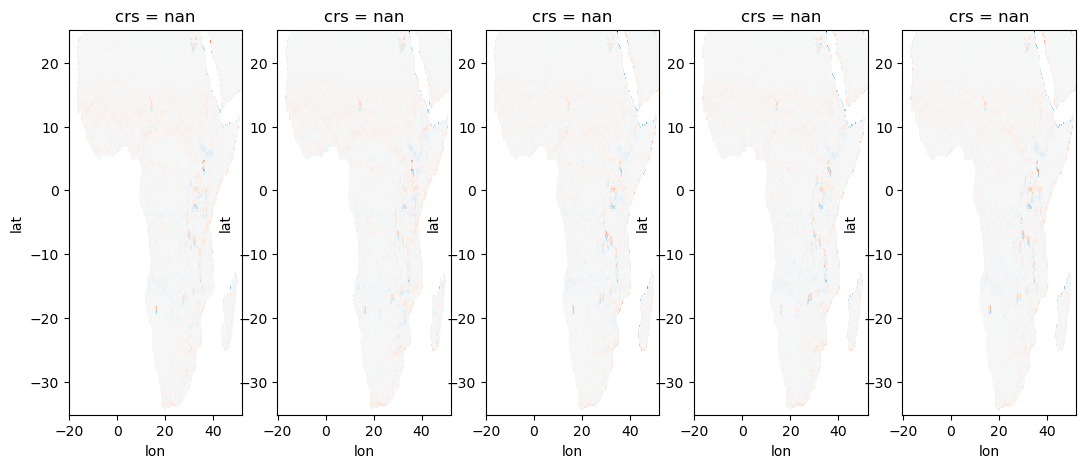

In [19]:
fig, ax = plt.subplots(ncols=5)

gradmer_gal_lh_tmean.where(gradmer_gal_lh_tmean < 0.1).plot(ax=ax[0], add_colorbar=False)
gradmer_com_lh_tmean.where(gradmer_com_lh_tmean < 0.1).plot(ax=ax[1], add_colorbar=False)
gradmer_ral_lh_tmean.where(gradmer_ral_lh_tmean < 0.1).plot(ax=ax[2], add_colorbar=False)
gradmer_ctc_lh_tmean.where(gradmer_ctc_lh_tmean < 0.1).plot(ax=ax[3], add_colorbar=False)
gradmer_lam_lh_tmean.where(gradmer_lam_lh_tmean < 0.1).plot(ax=ax[4], add_colorbar=False)

fig.set_size_inches(13., 5.)

In [20]:
diff_lap_com = gradmer_com_lh_tmean - gradmer_gal_lh_tmean
diff_lap_ral = gradmer_ral_lh_tmean - gradmer_gal_lh_tmean
diff_lap_ctc = gradmer_ctc_lh_tmean - gradmer_gal_lh_tmean
diff_lap_lam = gradmer_lam_lh_tmean - gradmer_gal_lh_tmean

diff_lap_com_sh = gradmer_com_sh_tmean - gradmer_gal_sh_tmean
diff_lap_ral_sh = gradmer_ral_sh_tmean - gradmer_gal_sh_tmean
diff_lap_ctc_sh = gradmer_ctc_sh_tmean - gradmer_gal_sh_tmean
diff_lap_lam_sh = gradmer_lam_sh_tmean - gradmer_gal_sh_tmean

In [21]:
print(diff_lap_com.min().values, diff_lap_ral.min().values, diff_lap_ctc.min().values, diff_lap_lam.min().values)
print(diff_lap_com.max().values, diff_lap_ral.max().values, diff_lap_ctc.max().values, diff_lap_lam.max().values)

-0.0038367359697032734 -0.013988726332055603 -0.014673455111773797 -0.015201536111770282
0.004066959323939341 0.007544959426139662 0.008193989319350514 0.008386818951892853


In [22]:
print(diff_lap_com_sh.min().values, diff_lap_ral_sh.min().values, diff_lap_ctc_sh.min().values, diff_lap_lam_sh.min().values)
print(diff_lap_com_sh.max().values, diff_lap_ral_sh.max().values, diff_lap_ctc_sh.max().values, diff_lap_lam_sh.max().values)

-0.003156342451289609 -0.005498578338933876 -0.005475851469980847 -0.0056653668329754315
0.0028542214831085645 0.004644167222917784 0.005431192145312333 0.005267626097062266


In [23]:
vlim = 0.25
diff_lap_com= diff_lap_com.where(abs(diff_lap_com) < vlim)
diff_lap_ral= diff_lap_ral.where(abs(diff_lap_ral) < vlim)
diff_lap_ctc= diff_lap_ctc.where(abs(diff_lap_ctc) < vlim)
diff_lap_lam= diff_lap_lam.where(abs(diff_lap_lam) < vlim)

vlim_sh = 0.1
diff_lap_com_sh = diff_lap_com_sh.where(abs(diff_lap_com_sh) < vlim_sh)
diff_lap_ral_sh = diff_lap_ral_sh.where(abs(diff_lap_ral_sh) < vlim_sh)
diff_lap_ctc_sh = diff_lap_ctc_sh.where(abs(diff_lap_ctc_sh) < vlim_sh)
diff_lap_lam_sh = diff_lap_lam_sh.where(abs(diff_lap_lam_sh) < vlim_sh)

/tmp/ipykernel_1694/4035817613.py:16: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 5 Axes> than <Figure size 640x480 with 4 Axes> which fig.colorbar is called on.
  plt.colorbar(p, ax=ax[:], orientation='horizontal', label='$\\nabla_y$LH [W m$^{-2}$ km$^{-1}$]', shrink=0.5, pad=0.1)


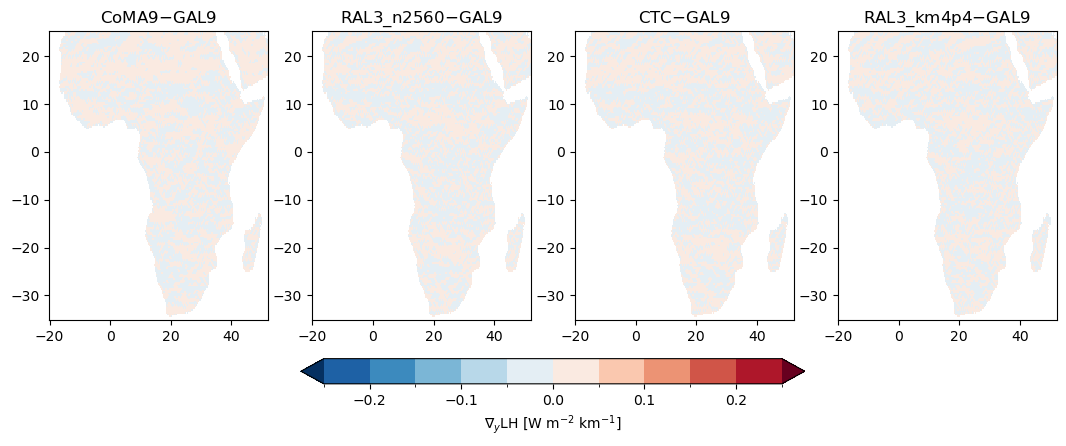

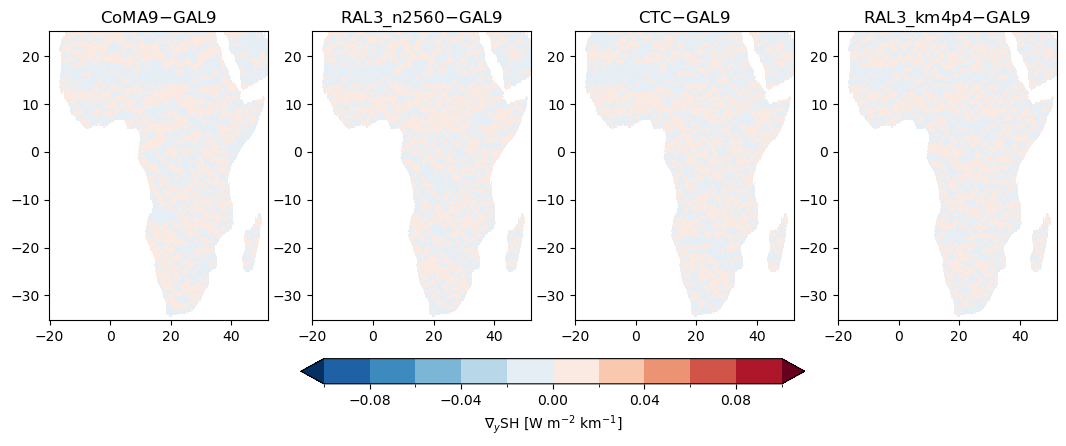

In [24]:
cmap = plt.get_cmap('RdBu_r')

bounds_lh = np.linspace(-vlim, vlim, 11)
norm_lh = BoundaryNorm(bounds_lh, cmap.N, extend='both')
bounds_sh = np.linspace(-vlim_sh, vlim_sh, 11)
norm_sh = BoundaryNorm(bounds_sh, cmap.N, extend='both')

fig, ax = plt.subplots(ncols=4)
fig_sh, ax_sh = plt.subplots(ncols=4)

p = diff_lap_com.plot(ax=ax[0], norm=norm_lh, cmap=cmap, add_colorbar=False)  # vmin=-vlim, vmax=vlim
diff_lap_ral.plot(ax=ax[1], norm=norm_lh, cmap=cmap, add_colorbar=False)
diff_lap_ctc.plot(ax=ax[2], norm=norm_lh, cmap=cmap, add_colorbar=False)
diff_lap_lam.plot(ax=ax[3], norm=norm_lh, cmap=cmap, add_colorbar=False)

plt.colorbar(p, ax=ax[:], orientation='horizontal', label='$\\nabla_y$LH [W m$^{-2}$ km$^{-1}$]', shrink=0.5, pad=0.1)

p_sh = diff_lap_com_sh.plot(ax=ax_sh[0], norm=norm_sh, cmap=cmap, add_colorbar=False)
diff_lap_ral_sh.plot(ax=ax_sh[1], norm=norm_lh, cmap=cmap, add_colorbar=False)
diff_lap_ctc_sh.plot(ax=ax_sh[2], norm=norm_lh, cmap=cmap, add_colorbar=False)
diff_lap_lam_sh.plot(ax=ax_sh[3], norm=norm_lh, cmap=cmap, add_colorbar=False)

plt.colorbar(p_sh, ax=ax_sh[:], orientation='horizontal', label='$\\nabla_y$SH [W m$^{-2}$ km$^{-1}$]', shrink=0.5, pad=0.1)


ax[0].set_title('CoMA9$-$GAL9')
ax[1].set_title('RAL3_n2560$-$GAL9')
ax[2].set_title('CTC$-$GAL9')
ax[3].set_title('RAL3_km4p4$-$GAL9')
ax_sh[0].set_title('CoMA9$-$GAL9')
ax_sh[1].set_title('RAL3_n2560$-$GAL9')
ax_sh[2].set_title('CTC$-$GAL9')
ax_sh[3].set_title('RAL3_km4p4$-$GAL9')


ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[2].set_xlabel('')
ax[3].set_xlabel('')
ax[0].set_ylabel('')
ax[1].set_ylabel('')
ax[2].set_ylabel('')
ax[3].set_ylabel('')

ax_sh[0].set_xlabel('')
ax_sh[1].set_xlabel('')
ax_sh[2].set_xlabel('')
ax_sh[3].set_xlabel('')
ax_sh[0].set_ylabel('')
ax_sh[1].set_ylabel('')
ax_sh[2].set_ylabel('')
ax_sh[3].set_ylabel('')


fig.set_size_inches(13., 5.)
fig_sh.set_size_inches(13., 5.)

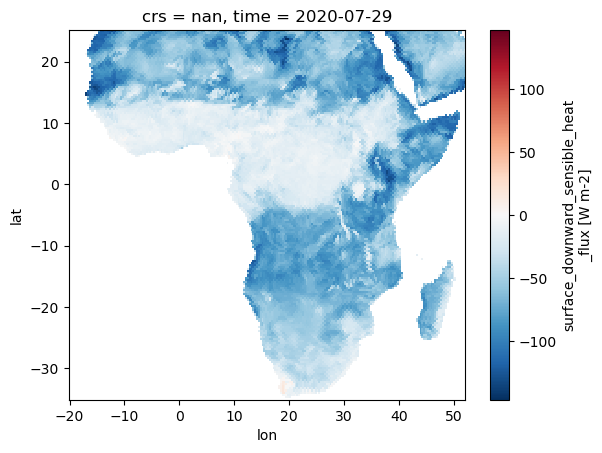

In [25]:
data_lam_sh.isel(time=day).plot()

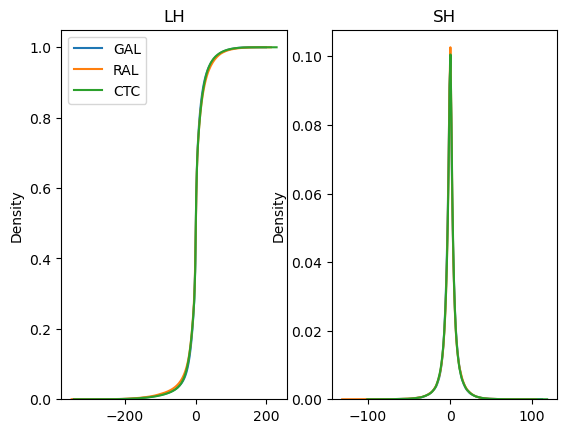

In [26]:
fig, ax = plt.subplots(ncols=2)

sb.kdeplot(data_gal_lh_ms.values.flatten(), ax=ax[0], cumulative=True, label='GAL') #, label='%.2f mm'%plow_glo)  # cumulative=True)
sb.kdeplot(data_ral_lh_ms.values.flatten(), ax=ax[0], cumulative=True, label='RAL') #, label='%.2f mm'%plow_glo)  # cumulative=True)
sb.kdeplot(data_ctc_lh_ms.values.flatten(), ax=ax[0], cumulative=True, label='CTC') #, label='%.2f mm'%plow_glo)  # cumulative=True)

sb.kdeplot(data_gal_sh_ms.values.flatten(), ax=ax[1], label='GAL') #, label='%.2f mm'%plow_glo)  # cumulative=True)
sb.kdeplot(data_ral_sh_ms.values.flatten(), ax=ax[1], label='RAL') #, label='%.2f mm'%plow_glo)  # cumulative=True)
sb.kdeplot(data_ctc_sh_ms.values.flatten(), ax=ax[1], label='CTC') #, label='%.2f mm'%plow_glo)  # cumulative=True)

ax[0].set_title('LH')
ax[1].set_title('SH')
ax[0].legend(loc='upper left')

Correlation
-

/tmp/ipykernel_1694/1892733996.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_gal_ms = pearsonr(data_gal_lh_ms, data_gal_sh_ms, axis=0)
/tmp/ipykernel_1694/1892733996.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_com_ms = pearsonr(data_com_lh_ms, data_com_sh_ms, axis=0)
/tmp/ipykernel_1694/1892733996.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_ral_ms = pearsonr(data_ral_lh_ms, data_ral_sh_ms, axis=0)
/tmp/ipykernel_1694/1892733996.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_ctc_ms = pearsonr(data_ctc_lh_ms, data_ctc_sh_ms, axis=0)
/tmp/ipykernel_1694/1892733996.py:50: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_lam_ms = pearsonr(data_lam_lh_ms, data_lam_sh_ms, axis=0)


nan


/tmp/ipykernel_1694/1892733996.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_gal_ms = pearsonr(data_gal_lh_ms, data_gal_sh_ms, axis=0)
/tmp/ipykernel_1694/1892733996.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_com_ms = pearsonr(data_com_lh_ms, data_com_sh_ms, axis=0)
/tmp/ipykernel_1694/1892733996.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_ral_ms = pearsonr(data_ral_lh_ms, data_ral_sh_ms, axis=0)


nan


/tmp/ipykernel_1694/1892733996.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_gal_ms = pearsonr(data_gal_lh_ms, data_gal_sh_ms, axis=0)
/tmp/ipykernel_1694/1892733996.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_com_ms = pearsonr(data_com_lh_ms, data_com_sh_ms, axis=0)
/tmp/ipykernel_1694/1892733996.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_ral_ms = pearsonr(data_ral_lh_ms, data_ral_sh_ms, axis=0)
/tmp/ipykernel_1694/1892733996.py:50: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_lam_ms = pearsonr(data_lam_lh_ms, data_lam_sh_ms, axis=0)
/tmp/ipykernel_1694/1892733996.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_gal_ms = pearsonr(data_gal_lh_ms, data_gal_sh_ms, axis=0)


nan


/tmp/ipykernel_1694/1892733996.py:39: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_ctc_ms = pearsonr(data_ctc_lh_ms, data_ctc_sh_ms, axis=0)
/tmp/ipykernel_1694/1892733996.py:50: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr_lam_ms = pearsonr(data_lam_lh_ms, data_lam_sh_ms, axis=0)
/tmp/ipykernel_1694/1892733996.py:162: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 21 Axes> than <Figure size 640x480 with 16 Axes> which fig.colorbar is called on.
  cb = plt.colorbar(p, ax=ax[:], orientation='horizontal', label='$\\rho$', shrink=0.5, pad=0.05)


1.2805479


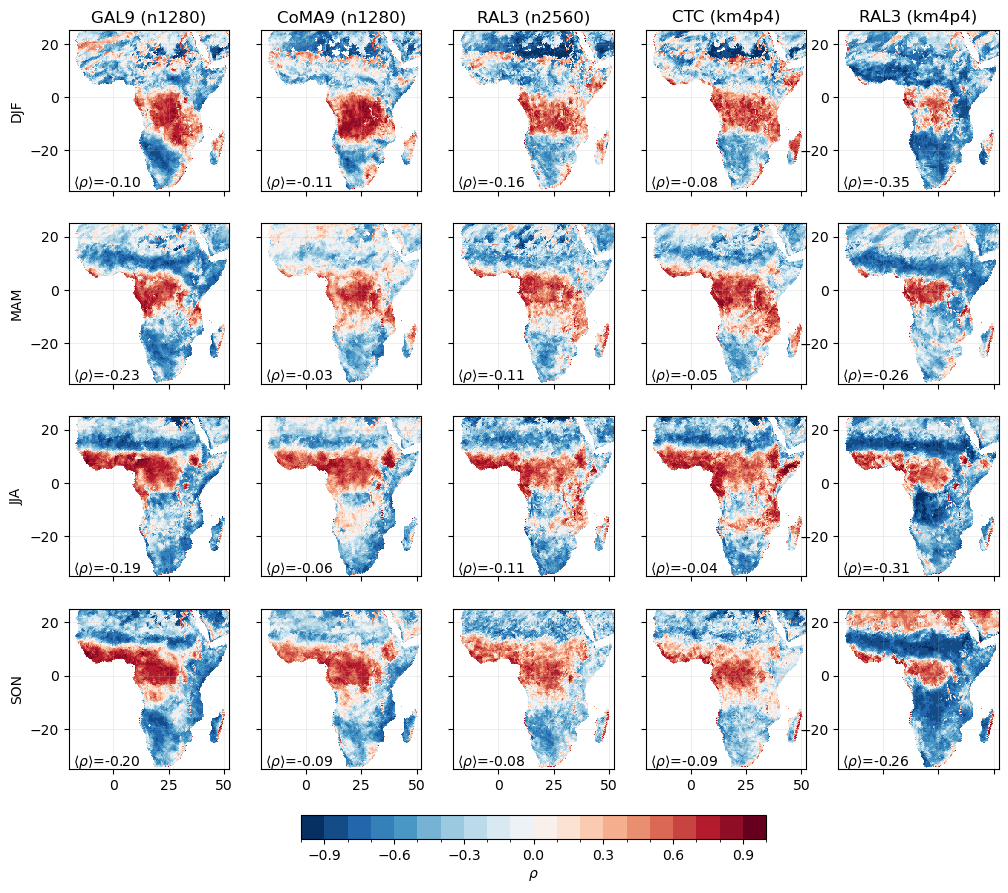

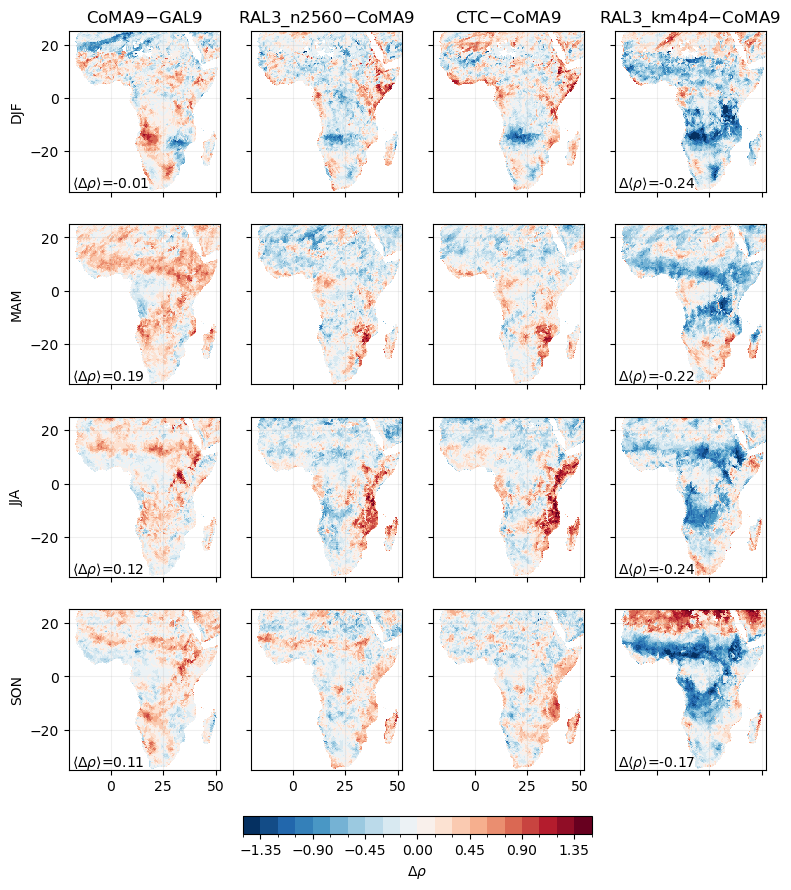

In [27]:
#~ Plot correlation

cmap = plt.get_cmap('RdBu_r')

bounds = np.linspace(-1., 1., 21)
norm = BoundaryNorm(bounds, cmap.N)
bounds_diff = np.linspace(-1.5, 1.5, 21)
norm_diff = BoundaryNorm(bounds_diff, cmap.N)

if region == 'Africa':
    ncols = 5
    ncols_diff = 4
else:
    ncols = 4
    ncols_diff = 3

fig, ax = plt.subplots(ncols=ncols, nrows=4)
fig_diff, ax_diff = plt.subplots(ncols=ncols_diff, nrows=4)

for i, (seas, mths) in enumerate(months_all.items()):
    lmonths = [imths[m] for m in mths]
    lmonths = list(itertools.chain(*lmonths))

    ax_ = ax[i]
    ax_diff_ = ax_diff[i]

    data_gal_lh_ms = data_gal_lh_ano.isel(time=lmonths)
    data_gal_sh_ms = data_gal_sh_ano.isel(time=lmonths)
    data_com_lh_ms = data_com_lh_ano.isel(time=lmonths)
    data_com_sh_ms = data_com_sh_ano.isel(time=lmonths)
    data_ral_lh_ms = data_ral_lh_ano.isel(time=lmonths)
    data_ral_sh_ms = data_ral_sh_ano.isel(time=lmonths)
    data_ctc_lh_ms = data_ctc_lh_ano.isel(time=lmonths)
    data_ctc_sh_ms = data_ctc_sh_ano.isel(time=lmonths)

    pr_gal_ms = pearsonr(data_gal_lh_ms, data_gal_sh_ms, axis=0)
    pr_com_ms = pearsonr(data_com_lh_ms, data_com_sh_ms, axis=0)
    pr_ral_ms = pearsonr(data_ral_lh_ms, data_ral_sh_ms, axis=0)
    pr_ctc_ms = pearsonr(data_ctc_lh_ms, data_ctc_sh_ms, axis=0)

    rs_gal_ms = pr_gal_ms[0]
    rs_com_ms = pr_com_ms[0]
    rs_ral_ms = pr_ral_ms[0]
    rs_ctc_ms = pr_ctc_ms[0]

    if region == 'Africa':
        data_lam_lh_ms = data_lam_lh.isel(time=lmonths)
        data_lam_sh_ms = data_lam_sh.isel(time=lmonths)

        pr_lam_ms = pearsonr(data_lam_lh_ms, data_lam_sh_ms, axis=0)

        rs_lam_ms = pr_lam_ms[0]
        rs_lam_ms = ma.masked_array(rs_lam_ms, mask=~land_mask)
        rs_lam_ms_mean = np.nanmean(rs_lam_ms)

        diff_lam_ms = rs_lam_ms - rs_com_ms
        diff_lam_ms_mean = np.nanmean(diff_lam_ms)

        ax_[4].pcolormesh(lons, lats, rs_lam_ms, norm=norm, cmap=cmap)
        ax_[4].text(0.025, 0.025, '$\\langle \\rho \\rangle$=%.2f'%rs_lam_ms_mean, transform=ax_[4].transAxes)
        ax_[4].grid(True, alpha=0.2)
        ax_[4].set_xticklabels([])

        ax_diff_[3].pcolormesh(lons, lats, diff_lam_ms, norm=norm_diff, cmap=cmap)
        ax_diff_[3].text(0.025, 0.025, '$\\Delta\\langle \\rho \\rangle$=%.2f'%diff_lam_ms_mean, transform=ax_diff_[3].transAxes)
        ax_diff_[3].grid(True, alpha=0.2)
        ax_diff_[3].set_xticklabels([])
        ax_diff_[3].set_yticklabels([])


    rs_gal_ms = ma.masked_array(rs_gal_ms, mask=~land_mask)
    rs_com_ms = ma.masked_array(rs_com_ms, mask=~land_mask)
    rs_ral_ms = ma.masked_array(rs_ral_ms, mask=~land_mask)
    rs_ctc_ms = ma.masked_array(rs_ctc_ms, mask=~land_mask)

    diff_com_ms = rs_com_ms - rs_gal_ms
    diff_ral_ms = rs_ral_ms - rs_com_ms
    diff_ctc_ms = rs_ctc_ms - rs_com_ms

    print(max(abs(diff_ral_ms.min()), abs(diff_ral_ms.max()), abs(diff_ctc_ms.min()), abs(diff_ctc_ms.max())))

    
    rs_gal_ms_mean = np.nanmean(rs_gal_ms)
    rs_com_ms_mean = np.nanmean(rs_com_ms)
    rs_ral_ms_mean = np.nanmean(rs_ral_ms)
    rs_ctc_ms_mean = np.nanmean(rs_ctc_ms)

    diff_com_ms_mean = np.nanmean(diff_com_ms)
    diff_ral_ms_mean = np.nanmean(diff_ral_ms)
    diff_ctc_ms_mean = np.nanmean(diff_ctc_ms)

    p = ax_[0].pcolormesh(lons, lats, rs_gal_ms, norm=norm, cmap=cmap)
    ax_[1].pcolormesh(lons, lats, rs_com_ms, norm=norm, cmap=cmap)
    ax_[2].pcolormesh(lons, lats, rs_ral_ms, norm=norm, cmap=cmap)
    ax_[3].pcolormesh(lons, lats, rs_ctc_ms, norm=norm, cmap=cmap)

    p_diff = ax_diff_[0].pcolormesh(lons, lats, diff_com_ms, norm=norm_diff, cmap=cmap)
    ax_diff_[1].pcolormesh(lons, lats, diff_ral_ms, norm=norm_diff, cmap=cmap)
    ax_diff_[2].pcolormesh(lons, lats, diff_ctc_ms, norm=norm_diff, cmap=cmap)


    if (region == 'Africa') or (region == 'SEA'):
        ax_[0].text(0.025, 0.025, '$\\langle \\rho \\rangle$=%.2f'%rs_gal_ms_mean, transform=ax_[0].transAxes)
        ax_[1].text(0.025, 0.025, '$\\langle \\rho \\rangle$=%.2f'%rs_com_ms_mean, transform=ax_[1].transAxes)
        ax_[2].text(0.025, 0.025, '$\\langle \\rho \\rangle$=%.2f'%rs_ral_ms_mean, transform=ax_[2].transAxes)
        ax_[3].text(0.025, 0.025, '$\\langle \\rho \\rangle$=%.2f'%rs_ctc_ms_mean, transform=ax_[3].transAxes)
        ax_diff_[1].text(0.025, 0.025, '$\\langle \\Delta \\rho \\rangle$=%.2f'%diff_com_ms_mean, transform=ax_diff_[0].transAxes)
        ax_diff_[0].text(0.025, 0.025, '$\\langle \\Delta \\rho \\rangle$=%.2f'%diff_ral_ms_mean, transform=ax_diff_[1].transAxes)
        ax_diff_[1].text(0.025, 0.025, '$\\langle \\Delta \\rho \\rangle$=%.2f'%diff_ctc_ms_mean, transform=ax_diff_[2].transAxes)
    elif region == 'SAmer':
        ax_[0].text(0.55, 0.92, '$\\langle \\rho \\rangle$=%.2f'%rs_gal_ms_mean, transform=ax_[0].transAxes)
        ax_[1].text(0.55, 0.92, '$\\langle \\rho \\rangle$=%.2f'%rs_com_ms_mean, transform=ax_[1].transAxes)
        ax_[2].text(0.55, 0.92, '$\\langle \\rho \\rangle$=%.2f'%rs_ral_ms_mean, transform=ax_[2].transAxes)
        ax_[3].text(0.55, 0.92, '$\\langle \\rho \\rangle$=%.2f'%rs_ctc_ms_mean, transform=ax_[3].transAxes)
        ax_diff_[0].text(0.55, 0.92, '$\\langle \\Delta\\rho \\rangle$=%.2f'%diff_com_ms_mean, transform=ax_diff_[0].transAxes)
        ax_diff_[1].text(0.55, 0.92, '$\\langle \\Delta\\rho \\rangle$=%.2f'%diff_ral_ms_mean, transform=ax_diff_[1].transAxes)
        ax_diff_[2].text(0.55, 0.92, '$\\langle \\Delta\\rho \\rangle$=%.2f'%diff_ctc_ms_mean, transform=ax_diff_[2].transAxes)

    ax_[1].set_yticklabels([])
    ax_[2].set_yticklabels([])
    ax_[3].set_yticklabels([])
    ax_[0].set_ylabel(seas)
    ax_[0].grid(True, alpha=0.2)
    ax_[1].grid(True, alpha=0.2)
    ax_[2].grid(True, alpha=0.2)
    ax_[3].grid(True, alpha=0.2)
    ax_diff_[1].set_yticklabels([])
    ax_diff_[2].set_yticklabels([])
    ax_diff_[0].set_ylabel(seas)
    ax_diff_[0].grid(True, alpha=0.2)
    ax_diff_[1].grid(True, alpha=0.2)
    ax_diff_[2].grid(True, alpha=0.2)
    if region == 'Africa':
        ax_diff_[3].grid(True, alpha=0.2)

    if i == 0:
        ax_[0].set_title('GAL9 (n1280)')
        ax_[1].set_title('CoMA9 (n1280)')
        ax_[2].set_title('RAL3 (n2560)')
        ax_[3].set_title('CTC (km4p4)')
        ax_diff_[0].set_title('CoMA9$-$GAL9')
        ax_diff_[1].set_title('RAL3_n2560$-$CoMA9')
        ax_diff_[2].set_title('CTC$-$CoMA9')
        if region == 'Africa':
            ax_[4].set_title('RAL3 (km4p4)')
            ax_diff_[3].set_title('RAL3_km4p4$-$CoMA9')
    else:
        ax_[0].set_title('')
        ax_[1].set_title('')
        ax_[2].set_title('')
        ax_[3].set_title('')

    if i != 3:
        ax_[0].set_xticklabels([])
        ax_[1].set_xticklabels([])
        ax_[2].set_xticklabels([])
        ax_[3].set_xticklabels([])
        ax_diff_[0].set_xticklabels([])
        ax_diff_[1].set_xticklabels([])
        ax_diff_[2].set_xticklabels([])

cb = plt.colorbar(p, ax=ax[:], orientation='horizontal', label='$\\rho$', shrink=0.5, pad=0.05)
cb_diff = plt.colorbar(p_diff, ax=ax_diff[:], orientation='horizontal', label='$\\Delta \\rho$', shrink=0.5, pad=0.05)

fig.set_size_inches(12., 12.)
fig_diff.set_size_inches(9., 12.)